In [11]:
#!{sys.executable} -m pip install h2o

  Using cached h2o-3.46.0.6-py2.py3-none-any.whl
  Using cached tabulate-0.9.0-py3-none-any.whl.metadata (34 kB)
Using cached tabulate-0.9.0-py3-none-any.whl (35 kB)


In [12]:
# Daniel Berhane Araya 2022

from datetime import date, datetime, timedelta
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.stats import poisson, gamma, burr, fisk
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import scipy as sp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import typing, random
import seaborn as sns
import calendar
import time

import h2o

h2o.init()

from h2o.estimators.deeplearning import H2OAutoEncoderEstimator


def load_input_data (fpath: str):
    
    """
    Loads input data
    :param fpath: The path of the input file, relative to the working directory (i.e., the directory in which the script is run)
    :return: The input dataset as a pandas data frame
    """

    df = pd.read_csv(fpath)
    print ("File Loaded")

    return df



def Complete_Timestamp (start, end, frequency):
       
    """
    Creates a dataframe with a Timestamp index column separated by a specified (frequency) time. The timestamp begins from start and finishes at end.  
    
    :param: start: The starting time
             end: The last time
       frequency: The time difference between each timestamp
       
    :return: a dataframe with a Timestamp index column separated by a specified (frequency) time 
    """
    
    l = (pd.DataFrame(columns=['NULL'], index=pd.date_range(start, end,freq=frequency))
         .between_time('00:00','23:45')
         .index.strftime('%Y-%m-%d %H:%M:%S')
         .tolist()
        )
    
    df = pd.DataFrame(l, columns=['Timestamp'])
    # df.set_index('Timestamp', inplace=True)
    
    return df


def sliding_window_energy (demand_raw, window_size, start, end, frequency):
    
    """
    :param: demand_raw: Raw demand dataset 
      
           window_size: This is used by the rolling_window function within this function to create an overlapping sliding window
                 start: Start timestamp
                   end: End timestamp
             frequency: The time frequency between each reading (15 min in this case)
       
    :return: A dataframe of overlapping sliding window demand data every frequency minutes. This is a complete dataset interms of time. Demand data not availble for 
             some dates are marked as nan and will be handled in the missing data treatment
    """
    
    # Raw demand timestamp data
    demand = demand_raw.copy() 
    
    demand.set_index('Timestamp', inplace=True)
    # Prepare a dataframe with complete records of data every frequency min (in this case 15min) from Start to end
    complete_timestamp = Complete_Timestamp (start, end, frequency)
    complete_timestamp.set_index('Timestamp', inplace=True)
    complete_timestamp.head()
    # Join the raw demand dataset to the complete timestamp data
    df = pd.merge (complete_timestamp, demand,  how='left', left_index=True, right_index=True)
    df.reset_index (inplace=True)
    
    # Extract temporal features from the timestamp field
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Year'] = pd.DatetimeIndex(df['Timestamp']).year
    df['Month'] = df['Timestamp'].dt.month
    #df['Month'] = df['Month'].astype("int64")
    
    df['DayOfMonth'] = pd.DatetimeIndex(df['Timestamp']).day
    df['Weekday'] = df['Timestamp'].dt.weekday
    
    # df['Weekday'] = df['Weekday'].astype("Int64")
      
    df['Hour'] = pd.DatetimeIndex(df['Timestamp']).hour
    df['Minute'] = pd.DatetimeIndex(df['Timestamp']).minute
    df['Date'] = df['Timestamp'].dt.date
    
    df = df[['Timestamp', 'Date', 'Month', 'DayOfMonth', 'Weekday', 'Hour', 'Minute', 'Demand']]
    demand_sw = rolling_window (df['Demand'].values, 5)
    demand_sw_df = pd.DataFrame (demand_sw)
    
    # Join the temporal features with the sliding window information
    demand_sw_time = pd.merge (df, demand_sw_df, how='inner', left_index=True, right_index=True)
  
    
    # demand_sw_time.set_index(['Date','Hour','Minute'], inplace=True)
    
    demand_sw_time.rename(
       columns={0: 'Demand_0', 1: 'Demand_15', 2: 'Demand_30', 3: 'Demand_45', 4: 'Demand_60'},
       inplace=True)
    
    demand_sw_time = demand_sw_time[['Timestamp', 'Month', 'DayOfMonth', 'Weekday','Hour','Minute', 'Demand_0', 'Demand_15',
       'Demand_30', 'Demand_45', 'Demand_60']]
    
    demand_sw_time.set_index('Timestamp', inplace=True)
    
    return demand_sw_time



def round_hour (row):
    
    """
    Rounds a timestamp column to the nearest hour. If the minutes < 30 min then it rounds it to that hour and if minutes > 30 min then to the next hour.
    
    :param: row: A row of a dataframe with a Timestamp column
       
    :return: A Dataframe with a Timestamp column rounded to the nearest hour
    """
    
    t = row['Timestamp']
    
    # Rounds to nearest hour by adding a timedelta hour if minute >= 30
    return (t.replace(second=0, microsecond=0, minute=0, hour=t.hour)
               +timedelta(hours=t.minute//30))


def weather_data_prepare (weather_raw, start, end, frequency):
    
    """
    Prepares a weather data with complete timestamp from start to end with every frequency minutes.
    
    :param: weather_raw: Raw weather data
                  start: Start timestamp date
                    end: End timestamp date
              frequency: The frequency of the data (15 min in this case)
       
    :return: A Dataframe full start to end every frequency minutes. Note that data is not cleaned at this point.
    """
    
    
    # Get a copy of the row data
    df = weather_raw.copy()
    
    # Combine the Date and Time fields and create a Timestamp field
    df['Timestamp'] = pd.to_datetime(df['Date'] + " " + df ['Time'])
    
    df = df [['Timestamp', 'Temperature', 'Dew Point', 'Humidity',
           'Wind Speed', 'Wind Gust', 'Pressure', 'Precipitation', 'Wind',
           'Condition', 'Date', 'Time']]
      
    # Because the weather data is collected at random times ... e.g. 7:36 am ... the time is rounded to the next 
    # ... or previous hour depending on the minutes > 30 min to the next hour < 30 min to the previous hour  
    # Create new rounded timestamp
    df['new_Timestamp'] = df.apply (round_hour, axis=1)

    # Some timestamps are rounded to the same time, so the duplicates are dropped
    df.drop_duplicates(subset=['new_Timestamp'], keep='last', inplace=True)
   
    # Drop the old Timestamp and replace it with the rounded new Timestamp
    df.drop(['Timestamp'], axis=1, inplace=True)
    df.rename(columns={'new_Timestamp':'Timestamp'}, inplace=True)
    
    # Create a minute dataframe to eventually join to the weather data frame and finally add to the rounded hourly timestamp
    minute_records = minute_data (df.shape[0])
    df.reset_index(inplace=True, drop=True)
    
    # To prepare for the minutes, repeat each hourly row four times ... this correstponds to (0, 15, 30 and 45) min
    df_d = df.loc[df.index.repeat(4)]
    df_d.reset_index(inplace=True)
    
    # Join the minutes dataframe to the weather data and remove duplicated columns
    df = pd.merge(df_d, minute_records, how="left", left_index=True, right_index=True)
    df.drop(['index_x', 'Time'], axis=1, inplace=True)
    
    df['C'] = df ['Timestamp'] + pd.to_timedelta (df['Minute'], unit='m')
    df.drop(['Timestamp', 'Date'], axis=1, inplace=True)
    df.rename(columns={"C":"Timestamp"}, inplace=True)
    df = df [['Timestamp', 'Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Wind Gust',
           'Pressure', 'Precipitation', 'Wind', 'Condition']]

    # So far, the dataset is not complete in terms of all timestamp. So eventually we have data from start to end
    complete_timestamp = Complete_Timestamp (start, end, frequency)
    
    complete_timestamp['Timestamp'] = pd.to_datetime(complete_timestamp['Timestamp'])
    
    complete_timestamp.set_index('Timestamp', inplace=True)
    df.set_index("Timestamp", inplace=True)
    
    # Join the weather data to the complete timestamp data
    df_t = pd.merge (complete_timestamp, df, how="left", left_index=True, right_index=True)
    
    # Select columns that are important for the modelling process
    df_t = df_t [['Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Wind Gust',
       'Pressure', 'Precipitation']]
  
    
    return (df_t)


def demand_missing_treatment (df):
    
    df.dropna(inplace=True)
    return df

def weather_missing_treatment (data):

    # weather data missing treatment
    # In this project missing weather data is imputted using the mean value of each hour of every month. For instance, missing temperature at 7 am in January is imputted by using
    # the mean value of all 7 am temperature values for January. Weather data is seasonal and it would be more appropriate to use the right season, in this case month for imputation
    data_c = data.copy()
    
    # Calculate mean values of weather parameter per month and hour
    imputted_values = data_c.groupby(['Month', 'Hour']).mean()
    imputted_values = imputted_values[['Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Wind Gust', 'Pressure', 'Precipitation']]
    imputted_values.reset_index(inplace=True)
    data_c.reset_index(inplace=True)
    
    # Merge mean values to weather data for later imputation
    data_imputted = pd.merge(data_c, imputted_values, how="left", left_on=['Month', 'Hour'], right_on=['Month', 'Hour'])
    
    # Imput missing data
    
    data_imputted['Temperature_x'].fillna(data_imputted['Temperature_y'], inplace=True)
    data_imputted['Dew Point_x'].fillna(data_imputted['Dew Point_y'], inplace=True)
    data_imputted['Humidity_x'].fillna(data_imputted['Humidity_y'], inplace=True)
    data_imputted['Wind Speed_x'].fillna(data_imputted['Wind Speed_y'], inplace=True)
    data_imputted['Wind Gust_x'].fillna(data_imputted['Wind Gust_y'], inplace=True)
    data_imputted['Pressure_x'].fillna(data_imputted['Pressure_y'], inplace=True)
    data_imputted['Precipitation_x'].fillna(data_imputted['Precipitation_y'], inplace=True)

    # Rename columns that were in common from the merger
    data_imputted.rename(
        columns={'Temperature_x': 'Temperature', 'Dew Point_x': 'Dew_Point', 'Humidity_x': 'Humidity',
                     'Pressure_x': 'Pressure', 'Wind Speed_x': 'Wind_Speed', 'Wind Gust_x': 'Wind_Gust',
                     'Precipitation_x': 'Precipitation'}, inplace=True)
  
    data_imputted = data_imputted [['Month', 'DayOfMonth', 'Weekday', 'Hour', 'Minute', 'Demand_0', 'Demand_15',
       'Demand_30', 'Demand_45', 'Demand_60', 'Temperature', 'Dew_Point',
       'Humidity', 'Wind_Speed', 'Wind_Gust', 'Pressure', 'Precipitation']]

    return (data_imputted)


def weather_combined_data (weather_data, sw_demand):
    
    """
    Combines weather data with demand sliding window data
    :param: weather_data: Weather data dataframe
               sw_demand: Sliding window demand data
               
    :return: Weather data and demand data combined
    """
    
    # The weather data is joined to the demand dataset
    
    weather_sw_demand = pd.merge(sw_demand, weather_data, how="left", left_index=True, right_index=True)
       
    weather_sw_demand.reset_index(inplace=True)
   
    
    # Remove duplicate features (Month_y) or fields that are not important to the learning process ('Day of Month or year') and demand is already included as a sliding window
    # weather_sw_demand.drop(['index', 'Month_y', 'DayOfMonth', 'Demand', 'Year', 'Date'], axis=1, inplace=True)

    weather_sw_demand.rename(
       columns={0: 'Demand_0', 1: 'Demand_15', 2: 'Demand_30', 3: 'Demand_45', 4: 'Demand_60'},
       inplace=True)
    
    # After analysing the dataset, Weekday is missing for the records with missing demand data. It's to be noted that Hour, Minute and Month are not missing because we are using
    # these from constracted full annual records. When we later do stratified train-test split, if we have any missing data (na) on any of the features used for stratified sampling
    # an error is thrown, therefore, the below line will for convinience fill forward the weekday. However it is to be noted that these records are the same records that have missing
    # demand and it is only because we will be removing these records that we are filling forward. If future implemetations include imputation techniques for demand, this line will be 
    # removed
    
    # weather_sw_demand.loc[:,'Weekday'] = weather_sw_demand.loc[:,'Weekday'].ffill()
    
    # There are some missing data in demand and these are only a few and have been removed from the dataset. Since we are dealing with a window of information, any record with
    # missing demand is entirely removed
    
    # demand_na = weather_sw_demand.isna().sum()
    
    # Remove a row that has any missing value
    #   weather_sw_demand.dropna(axis=0, inplace=True)
        
    # weather_sw_demand['Weekday'] = weather_sw_demand['Weekday'].astype(int)

    return (weather_sw_demand)


def minute_data (data_len):
    
    """
    Given a dataframe of length data_len, this function prepares a dataframe that's 4*data_len. In this case the 4 rows correspond to 0, 15, 30 and 45 minutes.
    
    :param: Length of the dataframe
       
    :return: A dataframe with a column Minute and contains 4 * data_len records.
    """
    
    minute_list = [n for n in range (0, 60, 15)]
    minute_list_df = pd.DataFrame (minute_list, columns={'Minute'})
    minute_index = pd.concat ([minute_list_df]*data_len, ignore_index=True)
    minute_index.reset_index(inplace=True)
    minute_index.rename(columns={0: 'Minute'}, inplace=True)

    return (minute_index)


def rolling_window(demand, window_size):
    
    """
    :param demand      : The demand dataset (one column)
           window_size : The size of the desired overlapping sliding window (in this project, I am examinining an hourly record measured 
                         every 15 minute interval, hence the window_size is 5 [0, 15, 30, 45, 0])
    :return            : A dataframe (5 columns) which is a sliding window of size 5 
    """
    shape = demand.shape[:-1] + (demand.shape[-1] - window_size + 1, window_size)
    strides = demand.strides + (demand.strides[-1],)
    return np.lib.stride_tricks.as_strided(demand, shape=shape, strides=strides)


def generate_features (df):
    
    """
    
    :param 
    :return: 
    """
    
    df['Demand_mean'] = df[['Demand_0', 'Demand_15', 'Demand_30', 'Demand_45', 'Demand_60']].mean(axis=1) 
    df['Demand_sd'] = df[['Demand_0', 'Demand_15', 'Demand_30', 'Demand_45', 'Demand_60']].std(axis=1)
    
    return (df)


def missing_treatment (df):
    
    """
    
    :param 
    :return: 
    """
    
    df.dropna(inplace=True)
    return df


def Quantile_transform (feature):
    
    """
    
    :param 
    :return: 
    """
    
    d = np.array (feature)
    # reshape data to have rows and columns
    data = d.reshape((len(d),1))
    # quantile transform the raw data
    quantile = QuantileTransformer(output_distribution='normal')
    feature_t= quantile.fit_transform(data)
    feature_t=feature_t.flatten()
    # histogram of the transformed data
    return pd.Series(feature_t)

def squared_transform (feature):
    
    """
    
    :param 
    :return: 
    """
    d = np.array (feature)
    feature_t = np.sqrt(d)
    feature_t = feature_t.flatten()
    return pd.Series(feature) 


def boxcox_transform (feature):
    
    """
    
    :param 
    :return: 
    """
    
    feature_c = np.array (feature)
    feature_t = stats.boxcox (feature_c, -1)
    feature_t = feature_t.flatten()
    return pd.Series (feature)  


def temporal_feature_cyclic (data):
    
    minutes_in_hour = 60
    hours_in_day = 24
    days_in_week = 7
    months_in_year = 12
    
    df = data.copy()
    
    df['sin_minutes'] = np.sin(2*np.pi*df['Minute']/minutes_in_hour)
    df['cos_minutes'] = np.cos(2*np.pi*df['Minute']/minutes_in_hour)
    
    df['sin_hours'] = np.sin(2*np.pi*df['Hour']/hours_in_day)
    df['cos_hours'] = np.cos(2*np.pi*df['Hour']/hours_in_day)
    
    df['sin_days'] = np.sin(2*np.pi*df['Weekday']/days_in_week)
    df['cos_days'] = np.cos(2*np.pi*df['Weekday']/days_in_week)
    
    df['sin_months'] = np.sin(2*np.pi*df['Month']/months_in_year)
    df['cos_months'] = np.cos(2*np.pi*df['Month']/months_in_year)
    
    #df.drop(['Hour', 'Weekday', 'Month'], axis=1, inplace=True)
    
    return (df)


def train_test_splitter (df):
    
    """
    
    :param 
    :return: 
    """
    
    split = StratifiedShuffleSplit (n_splits=1, test_size =0.2, random_state=42)

    for train_index, test_index in split.split (df, df[['Hour', 'Month', 'Weekday']]):
        strat_train_set = df.iloc[train_index]
        strat_test_set = df.iloc[test_index]
        
    return strat_train_set, strat_test_set



def gen_artificial_anomalous (row):
    
    """
    
    :param 
    :return: 
    """
    
    
    # find parameters of low-demand distribution
    # find parameters of high-demand distribution
    # if it's a weekday and hour >= 1 and hour <= 12 then generate 5 random numbers from the high-demand distribution 
    # if it's a weekday and hour > 12 and hour <= 23 then generate 5 random numbers from the low-demand distribution
    # if it's a weekend, then generate 5 random numbers from the high-demand distribution
    
    # high electric demand parameters
    c_high = 42.80
    d_high = 0.66
    loc_high = -1.16
    scale_high = 266.97
    
    # low electric demand parameters
    c_low = 42.53
    loc_low = -0.65
    scale_low = 222.14
    
    hour = int (row['Hour'])
    
    if ((hour >= 1 & hour <= 12)) | (hour >= 22) :
        # Note that the random_state is None so that we don't keep on generating the same random number
        demand = burr.rvs(c_high, d_high, loc=loc_high, scale=scale_high, size=5, random_state=None)
    
    elif (hour > 12 & hour) <= 21:
        demand = fisk.rvs(c_low, loc=loc_low, scale=scale_low, size=5, random_state=None)
    
    demand = np.around(demand,1)
    
    row ['Demand_0'] = demand [0]
    row ['Demand_15'] = demand [1]
    row ['Demand_30'] = demand [2]
    row ['Demand_45'] = demand [3]
    row ['Demand_60'] = demand [4]
    
    return row

def gen_artificial_anomalous_2 (row, demand_train_high, demand_train_low):
    
    """
    
    :param 
    :return: 
    """
    
    hour = int (row['Hour'])
    month = int (row['Month'])
    weekday = int (row['Weekday'])
    
    # find parameters of low-demand distribution
    # find parameters of high-demand distribution
    # if it's a weekday and hour >= 1 and hour <= 12 then generate 5 random numbers from the high-demand distribution 
    # if it's a weekday and hour > 12 and hour <= 23 then generate 5 random numbers from the low-demand distribution
    # if it's a weekend, then generate 5 random numbers from the high-demand distribution
    
    
    
    if ((hour >= 1 & hour <= 12)) | (hour >= 22) :
        index_high = random.sample (range(0,len(demand_train_high)), 5)
        demand = demand_train_high[index_high]
        
    elif (hour > 12 & hour) <= 21:
        index_high = random.sample (range(0,len(demand_train_low)), 5)
        demand = demand_train_high[index_low]
    
    demand = np.around(demand,1)
    
    row ['Demand_0'] = demand [0]
    row ['Demand_15'] = demand [1]
    row ['Demand_30'] = demand [2]
    row ['Demand_45'] = demand [3]
    row ['Demand_60'] = demand [4]
    
    return row



Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: java version "1.8.0_241"; Java(TM) SE Runtime Environment (build 1.8.0_241-b07); Java HotSpot(TM) 64-Bit Server VM (build 25.241-b07, mixed mode)
  Starting server from /Users/daniel/opt/anaconda3/envs/smart_building/lib/python3.11/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/n0/rlr196rj5qg7xs3j6brs4x_h0000gn/T/tmp2_ysclid
  JVM stdout: /var/folders/n0/rlr196rj5qg7xs3j6brs4x_h0000gn/T/tmp2_ysclid/h2o_daniel_started_from_python.out
  JVM stderr: /var/folders/n0/rlr196rj5qg7xs3j6brs4x_h0000gn/T/tmp2_ysclid/h2o_daniel_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_daniel_shuxqd
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.540 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


## Main ##

In [13]:
import pandas as pd
import numpy as np

import os

# -- Project imports

demand_input_path = '/Users/daniel/projects/anomaly_detection/electricB.csv'
weather_input_path ='/Users/daniel/projects/Python/anomaly_detection/dataset/'

years = [2016, 2017, 2018, 2019]


start = '2016-01-01 00:00:00'
end = '2019-12-31 23:45:00'

frequency = '15T'

# The interval of the timestamp
interval = 15

# Hourly sliding window dataset. The timestamp interval is 15 min. [0, 15, 30, 45, 0]
window_size = 5

data = pd.DataFrame()

# missing data
missing_demand = 0

demand = load_input_data (demand_input_path)

weather_data = pd.read_csv("/Users/daniel/projects/Python/anomaly_detection/dataset/weather_data.csv", thousands=',')

File Loaded


In [14]:
demand.isna().sum()

Timestamp    0
Demand       0
dtype: int64

In [15]:
weather_data.head()

,Unnamed: 0,Time,Temperature,Dew Point,Humidity,Wind Speed,Wind Gust,Pressure,Precipitation,Wind,Condition,Date
0,0,7:30 AM,-1,-3,86,9,0,976.19,0.0,WSW,Cloudy,2016-1-1
1,1,7:56 AM,-1,-3,86,9,0,976.19,0.0,WSW,Cloudy,2016-1-1
2,2,8:56 AM,-1,-3,86,11,0,976.19,0.0,WSW,Cloudy,2016-1-1
3,3,9:56 AM,-1,-2,93,15,0,976.19,0.0,WSW,Cloudy,2016-1-1
4,4,10:56 AM,-1,-2,93,17,0,976.19,0.0,WSW,Cloudy,2016-1-1


In [16]:
weather_data = weather_data [['Date', 'Time', 'Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Wind Gust', 'Pressure', 'Precipitation', 'Wind', 'Condition']]
weather_data.head()

,Date,Time,Temperature,Dew Point,Humidity,Wind Speed,Wind Gust,Pressure,Precipitation,Wind,Condition
0,2016-1-1,7:30 AM,-1,-3,86,9,0,976.19,0.0,WSW,Cloudy
1,2016-1-1,7:56 AM,-1,-3,86,9,0,976.19,0.0,WSW,Cloudy
2,2016-1-1,8:56 AM,-1,-3,86,11,0,976.19,0.0,WSW,Cloudy
3,2016-1-1,9:56 AM,-1,-2,93,15,0,976.19,0.0,WSW,Cloudy
4,2016-1-1,10:56 AM,-1,-2,93,17,0,976.19,0.0,WSW,Cloudy


In [17]:
demand_sw = sliding_window_energy (demand, 5, start, end, frequency)
demand_sw.head()

/var/folders/n0/rlr196rj5qg7xs3j6brs4x_h0000gn/T/ipykernel_1539/1537225579.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  l = (pd.DataFrame(columns=['NULL'], index=pd.date_range(start, end,freq=frequency))


,Month,DayOfMonth,Weekday,Hour,Minute,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60
Timestamp,,,,,,,,,,
2016-01-01 00:00:00,1,1,4,0,0,214.0,214.9,211.9,216.3,211.7
2016-01-01 00:15:00,1,1,4,0,15,214.9,211.9,216.3,211.7,206.3
2016-01-01 00:30:00,1,1,4,0,30,211.9,216.3,211.7,206.3,209.3
2016-01-01 00:45:00,1,1,4,0,45,216.3,211.7,206.3,209.3,209.2
2016-01-01 01:00:00,1,1,4,1,0,211.7,206.3,209.3,209.2,211.5


In [19]:
weather_data_p = weather_data_prepare (weather_data, start, end, frequency)

ValueError: columns cannot be a set

In [20]:
weather_data_p.head()

NameError: name 'weather_data_p' is not defined

In [9]:
weather_data_c = weather_combined_data (weather_data_p, demand_sw)
weather_data_c.head(41)
weather_data_c.set_index ('Timestamp', inplace=True)

In [10]:
data = weather_data_c.copy()

In [11]:
data.isna().sum()

Month               0
DayOfMonth          0
Weekday             0
Hour                0
Minute              0
Demand_0         1790
Demand_15        1790
Demand_30        1790
Demand_45        1790
Demand_60        1790
Temperature      2760
Dew Point        2760
Humidity         2760
Wind Speed       2760
Wind Gust        2760
Pressure         2760
Precipitation    2760
dtype: int64

In [12]:
data.shape

(140252, 17)

### Train-Test Split ###

Demand is highly seasonal, hence Hour, Month and Weekday are very important features. Depending on whether the building is residential or office, hourly demand varies greatly. For instance for residential, the demand would peak early in the morning when residents wake up and prepare to go to work or school and later in the evening when the residents come back home. Where as for office demand peaks early mornig hours and stays constant through out the day and then is low when everyone leaves home. This assumption is based on pre covid assessment because the work hours setting is now shifting to working from home for the most. Similarly, weekday and month also affect demand. Therefore the test set is generated by stratifying over these feature. Moreover, we know that the demand is also affected by the weekday as well as Month, hence we have stratified along all these features. The train test needs to be updated to accomodate future data so that the test data remains consistent.

In [13]:
# def train_test_splitter (df):
    
#    split = StratifiedShuffleSplit (n_splits=1, test_size = 0.2 , random_state=42)

#    for train_index, test_index in split.split (df, df[['Hour', 'Month', 'Weekday']]):
#        strat_train_set = df.iloc[train_index]
#        strat_test_set = df.iloc[test_index]
        
#    return strat_train_set, strat_test_set

strat_train_set, strat_test_set = train_test_splitter (data)
print ("Train: " + str(strat_train_set.shape[0]), "     Test: " + str (strat_test_set.shape[0]), "        Number of features: " + str (strat_test_set.shape[1]))

Train: 112201      Test: 28051         Number of features: 17


In [14]:
# Stratified by hour

dataset = data['Hour'].value_counts()/len(data['Hour'])
test_data = strat_test_set['Hour'].value_counts()/len(strat_test_set['Hour'])
hour_stratified = pd.concat([dataset, test_data], axis=1)
hour_stratified.reset_index (inplace=True)
hour_stratified.columns=['Hour', 'Entire Dataset', 'Test Dataset']
hour_stratified.set_index('Hour', inplace=True)

In [15]:
# Confirm hourly stratified test dataset - similar analysis can be done for Weekday and Month 
# There is 4.1% of each hour in the test dataset (similar to the entire dataset proportion)
hour_stratified.sort_values(by="Hour")

,Entire Dataset,Test Dataset
Hour,,
0,0.041668,0.041674
1,0.041668,0.041638
2,0.041668,0.041674
3,0.041668,0.041674
4,0.041668,0.041674
5,0.041668,0.041674
6,0.041668,0.041638
7,0.041668,0.041674
8,0.041668,0.041674


We will call the training dataset as *'demand_train'*. The model will be tested for its sensitivity and specificity. A part of the dataset split above will be used to evaluate the specificity of the model. The assumption is that the data extracted is normal (negative). We will call this dataset as  'negative_test'.  The next step is to generate an artificial anomalous dataset which we will call as 'positive_test' and will be used to evaluate the sensitivity of the mode</pre>

In [16]:
# Training dataset
demand_train = strat_train_set.copy()

# negative test dataset
negative_test = strat_test_set.copy()
demand_train.head()

,Month,DayOfMonth,Weekday,Hour,Minute,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60,Temperature,Dew Point,Humidity,Wind Speed,Wind Gust,Pressure,Precipitation
Timestamp,,,,,,,,,,,,,,,,,
2017-07-02 13:30:00,7,2,6,13,30,229.1,235.3,228.4,228.7,229.2,26.0,17.0,56.0,11.0,0.0,976.51,0.0
2018-02-25 04:00:00,2,25,6,4,0,230.3,232.8,234.4,230.1,233.8,3.0,2.0,93.0,22.0,31.0,975.21,0.3
2018-02-14 10:00:00,2,14,2,10,0,227.0,226.6,223.7,210.0,221.6,2.0,-2.0,78.0,15.0,0.0,983.35,0.0
2017-03-28 23:30:00,3,28,1,23,30,245.1,242.3,241.0,247.0,237.0,4.0,3.0,93.0,17.0,0.0,978.79,0.0
2019-09-18 04:45:00,9,18,2,4,45,212.4,221.9,222.2,217.1,204.9,7.0,7.0,100.0,7.0,0.0,984.32,0.0


### Missing data and outlier treatment ###

> Real-world *energy* **data** is full of outliers and missing data, this could be from equipment or power failure or other human-related errors. For instance, demand value should always be positive and a negative demand value represents anomalous. In this project, the approach adopted to treat missing data is as follows: 

>

> - Missing demand values were relatively few (1.3%) and for this reason, they were removed. There were several other options, this includes imputting the demand using median or mean of the approapriate hour, month and weekday. Note that the Hour, Minute, Moth and Weekday have similar missing values but in the below, we can see that the temporal features (Hour, Minute, ... ) have no missing data because of the way the data was prepared (Making sure that a complete timestamp is prepared and the dataset left joined to it.

> - Missing weather data: Weather data is highly seasonal to month and hour and hence missing values were imputted by using the mean of the weather parameter for the specific month and hour. In future studies, more rigorous imputation functions will be  explored to fit historic weather data for imputation purposes.

> - In this version of the project, the only outlier test that has been done was to check if there are negative demand values. Future work will explore multivariate outlier analysis techniques

In [17]:
# Missing data percentage
(demand_train.isna().sum()/len(demand_train))*100

Month            0.000000
DayOfMonth       0.000000
Weekday          0.000000
Hour             0.000000
Minute           0.000000
Demand_0         1.316388
Demand_15        1.306584
Demand_30        1.311040
Demand_45        1.300345
Demand_60        1.311931
Temperature      1.965223
Dew Point        1.965223
Humidity         1.965223
Wind Speed       1.965223
Wind Gust        1.965223
Pressure         1.965223
Precipitation    1.965223
dtype: float64

In [18]:
# demand_train = missing_treatment (demand_train)

In [19]:
demand_train_c = weather_missing_treatment (demand_train)

In [20]:
demand_train_c.isna().sum()

Month               0
DayOfMonth          0
Weekday             0
Hour                0
Minute              0
Demand_0         1477
Demand_15        1466
Demand_30        1471
Demand_45        1459
Demand_60        1472
Temperature         0
Dew_Point           0
Humidity            0
Wind_Speed          0
Wind_Gust           0
Pressure            0
Precipitation       0
dtype: int64

In [21]:
demand_train_cc = demand_missing_treatment(demand_train_c)

In [22]:
demand_train_cc.isna().sum()

Month            0
DayOfMonth       0
Weekday          0
Hour             0
Minute           0
Demand_0         0
Demand_15        0
Demand_30        0
Demand_45        0
Demand_60        0
Temperature      0
Dew_Point        0
Humidity         0
Wind_Speed       0
Wind_Gust        0
Pressure         0
Precipitation    0
dtype: int64

### Feature Generation ###

Partly, feature generation has been performed when a sliding window of hourly electric demand has been generated. In the future implementation, this implementation will be modularized to enable new other feature generation techniques to seemlessly integrate with the current framework.

In [23]:
# def generate_features (df):
    
#    df['Demand_mean'] = df[['Demand_0', 'Demand_15', 'Demand_30', 'Demand_45', 'Demand_60']].mean(axis=1) 
#    df['Demand_sd'] = df[['Demand_0', 'Demand_15', 'Demand_30', 'Demand_45', 'Demand_60']].sd(axis=1)
    
#    return (df)

demand_train_f = generate_features (demand_train_cc)
demand_train_f.head()

,Month,DayOfMonth,Weekday,Hour,Minute,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60,Temperature,Dew_Point,Humidity,Wind_Speed,Wind_Gust,Pressure,Precipitation,Demand_mean,Demand_sd
0,7,2,6,13,30,229.1,235.3,228.4,228.7,229.2,26.0,17.0,56.0,11.0,0.0,976.51,0.0,230.14,2.902241
1,2,25,6,4,0,230.3,232.8,234.4,230.1,233.8,3.0,2.0,93.0,22.0,31.0,975.21,0.3,232.28,1.984187
2,2,14,2,10,0,227.0,226.6,223.7,210.0,221.6,2.0,-2.0,78.0,15.0,0.0,983.35,0.0,221.78,6.945646
3,3,28,1,23,30,245.1,242.3,241.0,247.0,237.0,4.0,3.0,93.0,17.0,0.0,978.79,0.0,242.48,3.858368
4,9,18,2,4,45,212.4,221.9,222.2,217.1,204.9,7.0,7.0,100.0,7.0,0.0,984.32,0.0,215.70,7.248793


### Artificial Anomalous Dataset ###

Before generating anomalous artificial dataset, let's analyze the distribution of the dataset's hourly mean demand and daily mean demand

#### Hourly Electric Demand Distribution ####

In [24]:
new_demand = demand_train_f.reset_index(drop=True)

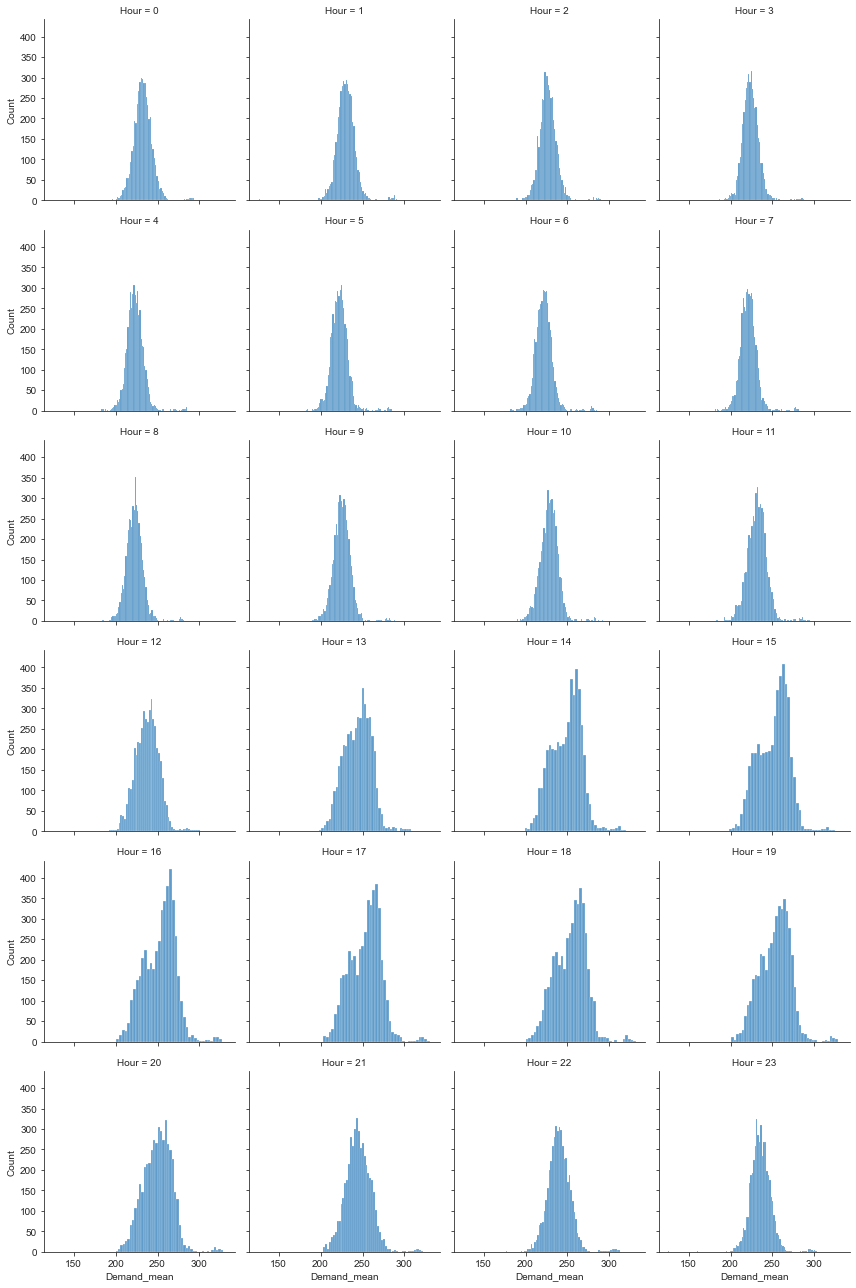

In [25]:
# Mean hourly electric demand distribution
sns.set_style("ticks")
g = sns.FacetGrid(new_demand, col="Hour", height=3, col_wrap=4)
_ = g.map_dataframe(sns.histplot, x="Demand_mean" , color="#2b7bba")

In [26]:
new_demand.head()

,Month,DayOfMonth,Weekday,Hour,Minute,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60,Temperature,Dew_Point,Humidity,Wind_Speed,Wind_Gust,Pressure,Precipitation,Demand_mean,Demand_sd
0,7,2,6,13,30,229.1,235.3,228.4,228.7,229.2,26.0,17.0,56.0,11.0,0.0,976.51,0.0,230.14,2.902241
1,2,25,6,4,0,230.3,232.8,234.4,230.1,233.8,3.0,2.0,93.0,22.0,31.0,975.21,0.3,232.28,1.984187
2,2,14,2,10,0,227.0,226.6,223.7,210.0,221.6,2.0,-2.0,78.0,15.0,0.0,983.35,0.0,221.78,6.945646
3,3,28,1,23,30,245.1,242.3,241.0,247.0,237.0,4.0,3.0,93.0,17.0,0.0,978.79,0.0,242.48,3.858368
4,9,18,2,4,45,212.4,221.9,222.2,217.1,204.9,7.0,7.0,100.0,7.0,0.0,984.32,0.0,215.70,7.248793


In [27]:
demand_train_f.head()

,Month,DayOfMonth,Weekday,Hour,Minute,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60,Temperature,Dew_Point,Humidity,Wind_Speed,Wind_Gust,Pressure,Precipitation,Demand_mean,Demand_sd
0,7,2,6,13,30,229.1,235.3,228.4,228.7,229.2,26.0,17.0,56.0,11.0,0.0,976.51,0.0,230.14,2.902241
1,2,25,6,4,0,230.3,232.8,234.4,230.1,233.8,3.0,2.0,93.0,22.0,31.0,975.21,0.3,232.28,1.984187
2,2,14,2,10,0,227.0,226.6,223.7,210.0,221.6,2.0,-2.0,78.0,15.0,0.0,983.35,0.0,221.78,6.945646
3,3,28,1,23,30,245.1,242.3,241.0,247.0,237.0,4.0,3.0,93.0,17.0,0.0,978.79,0.0,242.48,3.858368
4,9,18,2,4,45,212.4,221.9,222.2,217.1,204.9,7.0,7.0,100.0,7.0,0.0,984.32,0.0,215.70,7.248793


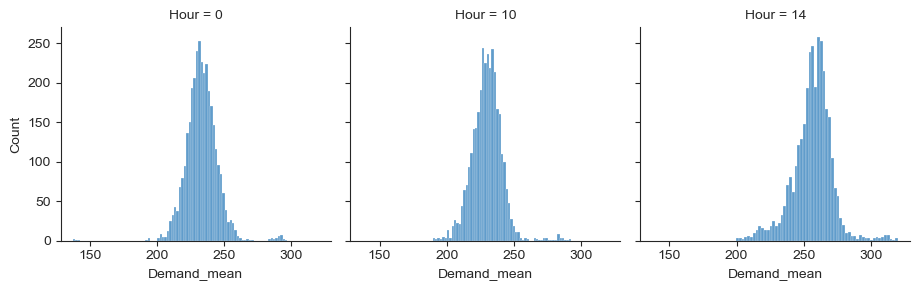

In [28]:
new_demand_hours = new_demand[((new_demand['Hour'] == 0 )  | (new_demand['Hour']  == 10) | (new_demand['Hour'] == 14)) & ((new_demand['Weekday'] != 5)  & (new_demand['Weekday'] != 6))]             

# Mean hourly electric demand distribution
sns.set_style("ticks")
g = sns.FacetGrid(new_demand_hours, col="Hour", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean" , color="#2b7bba")


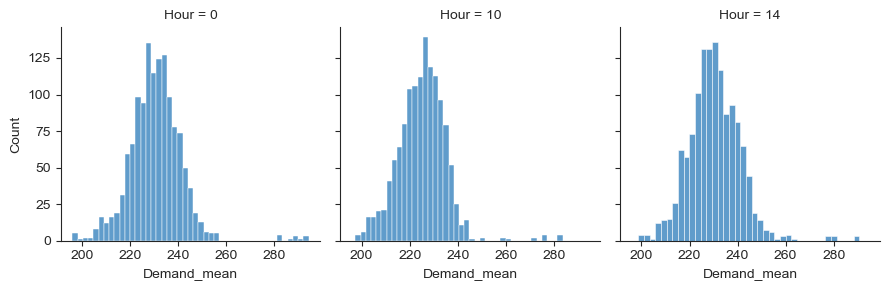

In [29]:
new_demand_hours = new_demand[((new_demand['Hour'] == 0 )  | (new_demand['Hour']  == 10) | (new_demand['Hour'] == 14)) & ((new_demand['Weekday'] == 5)  | (new_demand['Weekday'] == 6))]             

# Mean hourly electric demand distribution
sns.set_style("ticks")
g = sns.FacetGrid(new_demand_hours, col="Hour", height=3, col_wrap=3)
_ = g.map_dataframe(sns.histplot, x="Demand_mean" , color="#2b7bba")


### Daily Electric Demand Distribution ###

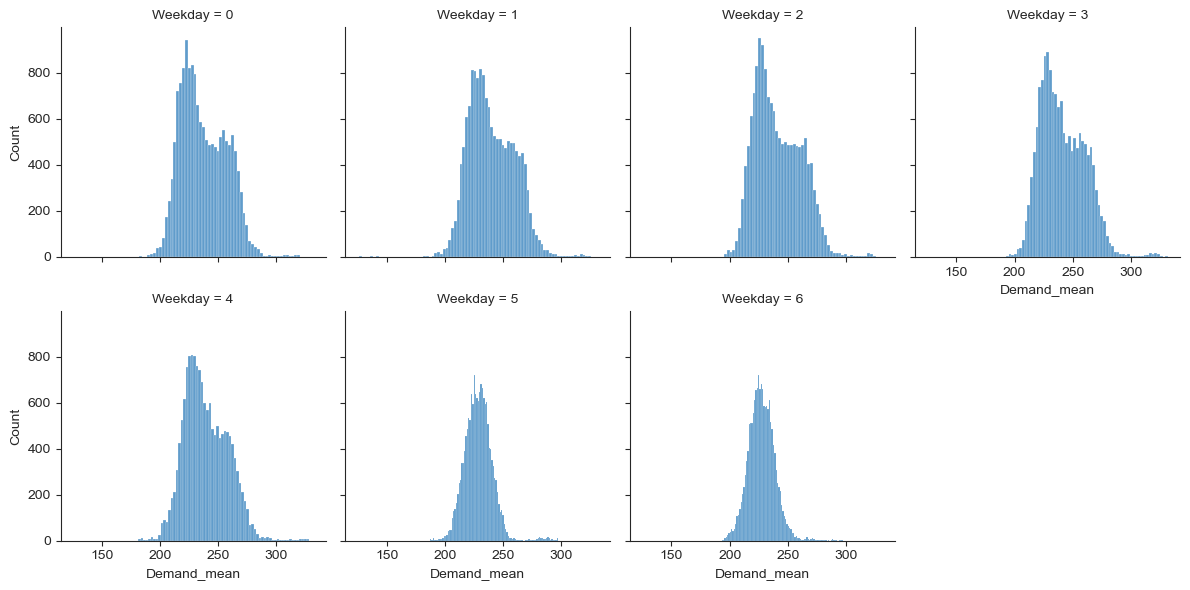

In [30]:
# Daily electric demand distribution
g = sns.FacetGrid(new_demand, col="Weekday", height=3, col_wrap=4)
_ = g.map_dataframe(sns.histplot, x="Demand_mean", color = "#2b7bba")
sns.set_style("ticks")

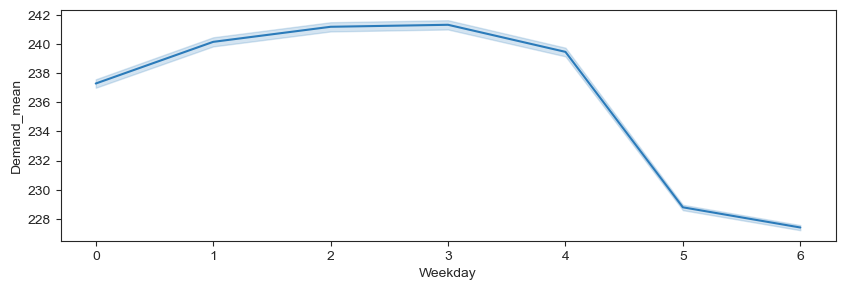

In [34]:
_ , ax = plt.subplots(figsize = (10, 3))
ax = sns.lineplot(data=new_demand , x="Weekday", y="Demand_mean", color="#2b7bba")

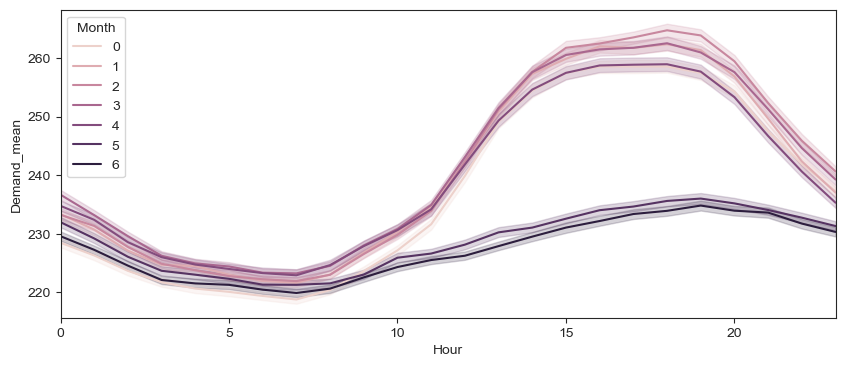

In [35]:
_ , ax = plt.subplots(figsize = (10, 4))
ax = sns.lineplot(data=new_demand, x="Hour", y="Demand_mean", hue="Weekday")
plt.xlim(0, 23)
_ = ax.legend(loc='upper left', title='Month')

As shown in the above charts, the hourly demand can be classified into high-demand hours (peak demand hours), i.e., weekdays [14-20], low-demand hours - weekdays [3-11] and the rest of the hours for weekday, the demand has medium. Moreover, if we observe the daily demand values, we can classify it into weekday (high demand) and weekend (low demand) days.

In this project, we will equally focus on both higher values of demand when we expect low, which shows energy waste as well as low values of demand when we expect high, which might indicate device malfunction

Several approaches can be used to generate artrificial anomalous dataset. For simplicity, the approach adopted in this project is to first identify the high-demand and low-demand hours/days, subsquently, extract the mean hourly demand for these two demand categories. Once we have the mean demand for these two categories, we search for the right distribution to fit these datasets. After getting the parameters of the right distributions, we generate random number from these distributions to populate the artificial anomalous dataset. For weekdays, low-demand hours are assigned demand values from the high-demand hours and similarly high-demand hours are assigned demand values from the low-demand hours. For weekends, since the demand is always low, high demand values will be used.

It is to be noted that can other temporal features, most importantly, 'month' can be used to further increase the granularity of the artificial dataset but in this first version, for simplicity, I will only look into the features 'Hour' and 'Weekday'. The second point is to ensure that the artificial anomalous dataset is representative of the whole sample, a stratified sampling approach is adopted where by the dataset is stratfied across the most important temporal features - 'Hour', 'Weekday' and 'Month'. A total of 27118 datasets will be generated.  

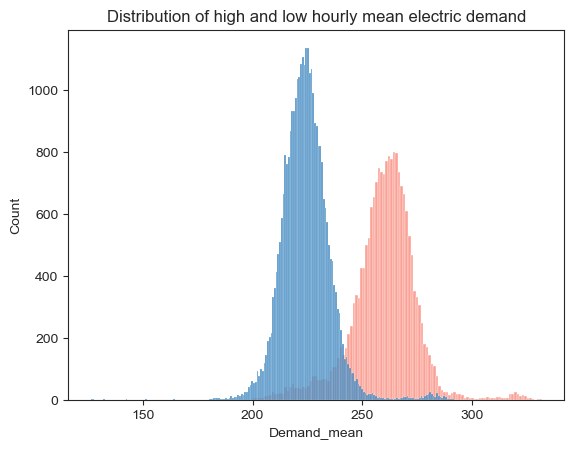

In [41]:
# Extract the high and low hourly mean electric demand
peak_demand_hours  = demand_train_f[(demand_train_f['Hour'] > 13)  & (demand_train_f['Hour'] < 20) & (demand_train_f['Weekday'] != 5)  & (demand_train_f['Weekday'] != 6)]
low_demand_hours = demand_train_f [(demand_train_f['Hour'] > 0)  & (demand_train_f['Hour'] < 8)]
ax = sns.histplot(peak_demand_hours['Demand_mean'], color="Salmon", legend=True).set(title='Distribution of high and low hourly mean electric demand')
ax = sns.histplot(low_demand_hours['Demand_mean'], color="#2b7bba")


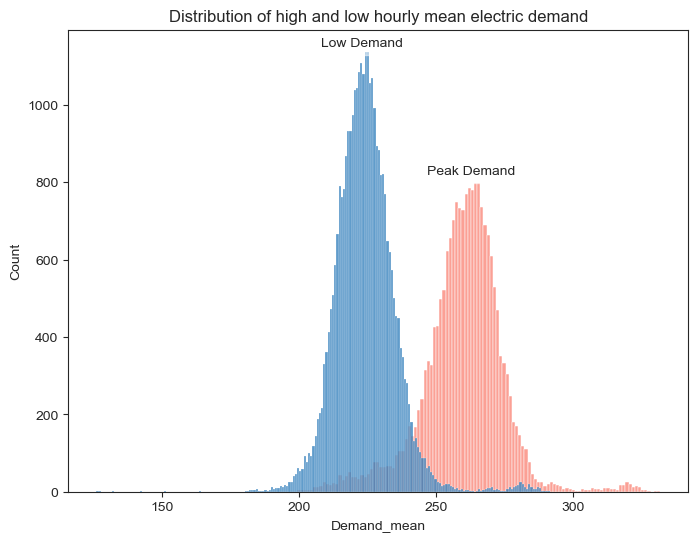

In [82]:
plt.figure(figsize=(8, 6))
# Extract the high and low hourly mean electric demand
peak_demand_hours  = demand_train_f[(demand_train_f['Hour'] > 13)  & (demand_train_f['Hour'] < 20) & (demand_train_f['Weekday'] != 5)  & (demand_train_f['Weekday'] != 6)]
low_demand_hours = demand_train_f [(demand_train_f['Hour'] > 0)  & (demand_train_f['Hour'] < 8)]
ax = sns.histplot(peak_demand_hours['Demand_mean'], color="Salmon", legend=True).set(title='Distribution of high and low hourly mean electric demand')
ax = sns.histplot(low_demand_hours['Demand_mean'], color="#2b7bba")


plt.text(263, 820, 'Peak Demand', bbox=dict(facecolor='white',
                   alpha=0.5),
         horizontalalignment='center',
         fontsize=10)
plt.text(223, 1150, 'Low Demand', bbox=dict(facecolor='white',
                   alpha=0.5),
         horizontalalignment='center',fontsize=10)

plt.show()

In [83]:
# Split test dataset and later populate with artificial anomalous dataset

def train_test_splitter (df):
    
    split = StratifiedShuffleSplit (n_splits=1, test_size = 0.2 , random_state=42)

    for train_index, test_index in split.split (df, df[['Hour', 'Month', 'Weekday']]):
        strat_train_set = df.iloc[train_index]
        strat_test_set = df.iloc[test_index]
        
          
    return strat_train_set, strat_test_set


# This is the same function used to split for the negative dataset. Also stratified using 'Hour', 'Month' and 'Weekday'
_ ,strat_anomalous_test_set = train_test_splitter (data)


# Positive test dataset split copy
positive_test = .copy()

### Another option to generate Artificial Anomalous Dataset ###

In [195]:
# Generate and populate artifiical anomalous dataset - make it to a function

# df = demand_train.copy()

# A list of high demands - Feb has high demand
# demand_train_high = np.array(df[(df['Month'] == 2) & (df['Hour'] == 19) & (df['Weekday'] != 5) & (df['Weekday']!= 6)]['Demand_mean'].values)
# demand_train_high.sort ()
# demand_train_high = demand_train_high[demand_train_high > 250]
# _ = sns.histplot(demand_train_high,  color="Salmon")


# A list of low demands - Jun has low demand
# demand_train_low = np.array (df[(df['Month'] == 6) & (df['Weekday'] != 5) & (df['Weekday'] != 6)]['Demand_mean'].values)
# demand_train_low.sort()
# demand_train_low = demand_train_low[demand_train_low < 240]
# _ = sns.histplot(demand_train_low, color="#2b7bba")


# Populate anomalous dataset this is not based on a random demand from a distribution
# positive_test = positive_test.apply(gen_artificial_anomalous_2, args=(demand_train_high, demand_train_low), axis=1)
# positive_test = pd.DataFrame (positive_test)



In [196]:
# Show they are equally stratified by Hour, Month and Weekday
pd.DataFrame(positive_test['Weekday'].value_counts()/len(positive_test['Weekday'])).sort_index()

,Weekday
0,0.142883
1,0.143703
2,0.142027
3,0.142847
4,0.142847
5,0.142811
6,0.142883


In [197]:
def gen_artificial_anomalous (row):
    
    # find parameters of low-demand distribution
    # find parameters of high-demand distribution
    # if it's a weekday and hour >= 1 and hour <= 12 then generate 5 random numbers from the high-demand distribution 
    # if it's a weekday and hour > 12 and hour <= 23 then generate 5 random numbers from the low-demand distribution
    # if it's a weekend, then generate 5 random numbers from the high-demand distribution
    
    # high electric demand parameters
    c_high = 42.80
    d_high = 0.66
    loc_high = -1.16
    scale_high = 266.97
    
    # low electric demand parameters
    c_low = 42.53
    loc_low = -0.65
    scale_low = 222.14
    
    hour = int (row['Hour'])
    
    if ((hour >= 1 & hour <= 12)) | (hour >= 22) :
        # Note that the random_state is None so that we don't keep on generating the same random number
        demand = burr.rvs(c_high, d_high, loc=loc_high, scale=scale_high, size=5, random_state=None)
    
    elif (hour > 12 & hour) <= 21:
        demand = fisk.rvs(c_low, loc=loc_low, scale=scale_low, size=5, random_state=None)
    
    demand = np.around(demand,1)
    
    row ['Demand_0'] = demand [0]
    row ['Demand_15'] = demand [1]
    row ['Demand_30'] = demand [2]
    row ['Demand_45'] = demand [3]
    row ['Demand_60'] = demand [4]
    
    return row

positive_test_backup = positive_test.apply(gen_artificial_anomalous, axis=1)
# positive_test_backup = positive_test_backup.astype({"Hour": int, "Month": int, "Weekday": int, "Minute": int})

In [198]:
positive_test_backup.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28051 entries, 2016-11-09 22:45:00 to 2018-07-13 10:30:00
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Month          28051 non-null  float64
 1   DayOfMonth     28051 non-null  float64
 2   Weekday        28051 non-null  float64
 3   Hour           28051 non-null  float64
 4   Minute         28051 non-null  float64
 5   Demand_0       28051 non-null  float64
 6   Demand_15      28051 non-null  float64
 7   Demand_30      28051 non-null  float64
 8   Demand_45      28051 non-null  float64
 9   Demand_60      28051 non-null  float64
 10  Temperature    27496 non-null  float64
 11  Dew Point      27496 non-null  float64
 12  Humidity       27496 non-null  float64
 13  Wind Speed     27496 non-null  float64
 14  Wind Gust      27496 non-null  float64
 15  Pressure       27496 non-null  float64
 16  Precipitation  27496 non-null  float64
dtypes: float64(17)


In [199]:
positive_test = positive_test_backup.copy()

In [200]:
positive_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28051 entries, 2016-11-09 22:45:00 to 2018-07-13 10:30:00
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Month          28051 non-null  float64
 1   DayOfMonth     28051 non-null  float64
 2   Weekday        28051 non-null  float64
 3   Hour           28051 non-null  float64
 4   Minute         28051 non-null  float64
 5   Demand_0       28051 non-null  float64
 6   Demand_15      28051 non-null  float64
 7   Demand_30      28051 non-null  float64
 8   Demand_45      28051 non-null  float64
 9   Demand_60      28051 non-null  float64
 10  Temperature    27496 non-null  float64
 11  Dew Point      27496 non-null  float64
 12  Humidity       27496 non-null  float64
 13  Wind Speed     27496 non-null  float64
 14  Wind Gust      27496 non-null  float64
 15  Pressure       27496 non-null  float64
 16  Precipitation  27496 non-null  float64
dtypes: float64(17)


### Comparing Distributions ###

Now let's check if the distribution we fit to the high and low hourly mean demand is correct. We will generate random demand values using the parameters (for both high and low) and compare them to the values we selected using the hour filter using Kolmogorov-Smirnov two-sample test.

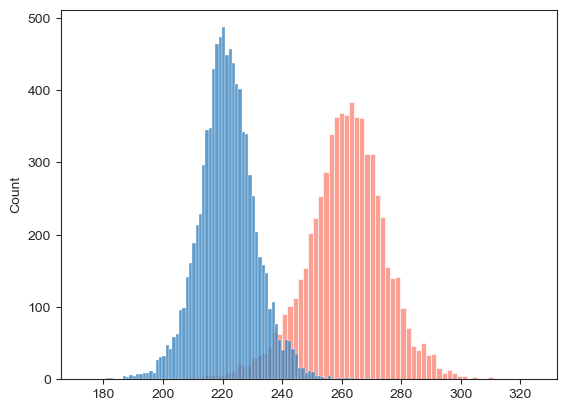

In [201]:
c_high = 42.80
d_high = 0.66
loc_high = -1.16
scale_high = 266.97

r_high = burr.rvs (c_high, d_high, loc_high, scale_high, size=6472, random_state=24)
_ = sns.histplot(r_high, color='Salmon')

c_low = 42.53
loc_low = -0.65
scale_low = 222.14

r_low = fisk.rvs(c_low, loc=loc_low, scale=scale_low, size=9053, random_state=24)
_ = sns.histplot (r_low, color="#2b7bba")

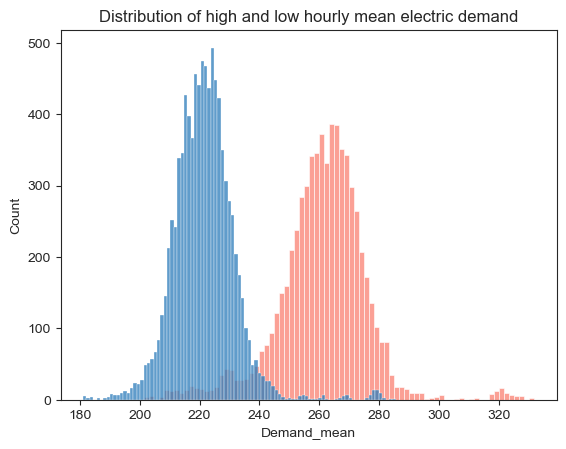

In [202]:
# Extract the high and low hourly mean electric demand
# Repeated for clarity
peak_demand_hours  = demand_train_f[(demand_train_f['Hour'] > 17)  & (demand_train_f['Hour'] < 20) & (demand_train_f['Weekday'] != 5)  & (demand_train_f['Weekday'] != 6)]
low_demand_hours = demand_train_f [(demand_train_f['Hour'] > 5)  & (demand_train_f['Hour'] < 8)]
_ = sns.histplot(peak_demand_hours['Demand_mean'], color="Salmon").set(title='Distribution of high and low hourly mean electric demand')
_ = sns.histplot(low_demand_hours['Demand_mean'], color="#2b7bba")

#### Verify Sampling Distribution for Anomalous Artificial Dataset ####

In [203]:
sp.stats.ks_2samp(r_low, low_demand_hours ['Demand_mean'].values, alternative='two-sided', mode='auto')

KstestResult(statistic=0.025572752801111504, pvalue=0.004948545551421004)

In [204]:
sp.stats.ks_2samp(r_high, peak_demand_hours ['Demand_mean'].values, alternative='two-sided', mode='auto') 

KstestResult(statistic=0.022318066727185143, pvalue=0.07642149722305969)

##### The pvalues of both tests is greater than 0.05, hence we can't reject the null hypothesis which states that the two distributions are identical. ##### 

## Exploratory Data Analysis ##

Now that we have split our training and test datasets, let's perform some exploratory data analysis of the training dataset.

The portal had demand dataset available from Jan 2015-June 2021. However, the dataset used in the modelling process is from Jan 2016 - Dec 2019. The reason this sample was selected is on the first hand, an observation of the annual demand shows that the facility had higher electric demand in 2015 compared to the following 6 years. There could be various reasons for this fall in demand: building or equipment renovation could be one example, or changes to the number of smart meters could be another. In any case, I believe that the electric demand for the year 2015 may not represent the current demand appetite of the building. Also, most probably because of the global pandemic related lockdown, there was a sudden fall in the demand after April 2020. For this reason, the dataset selected for this modelling exercise is from Jan 2016 - Dec 2019.

Similar to the previous paper, the key assumption made here is that the building behaves predominantly normal. The main reason behind this assumption is the lack of labeled dataset. To test the sensitivity of the models, an artificial anomaly dataset has been prepared and part of the dataset has also been set aside to test the specificity of the models.  

## Hourly mean demand distribution ##

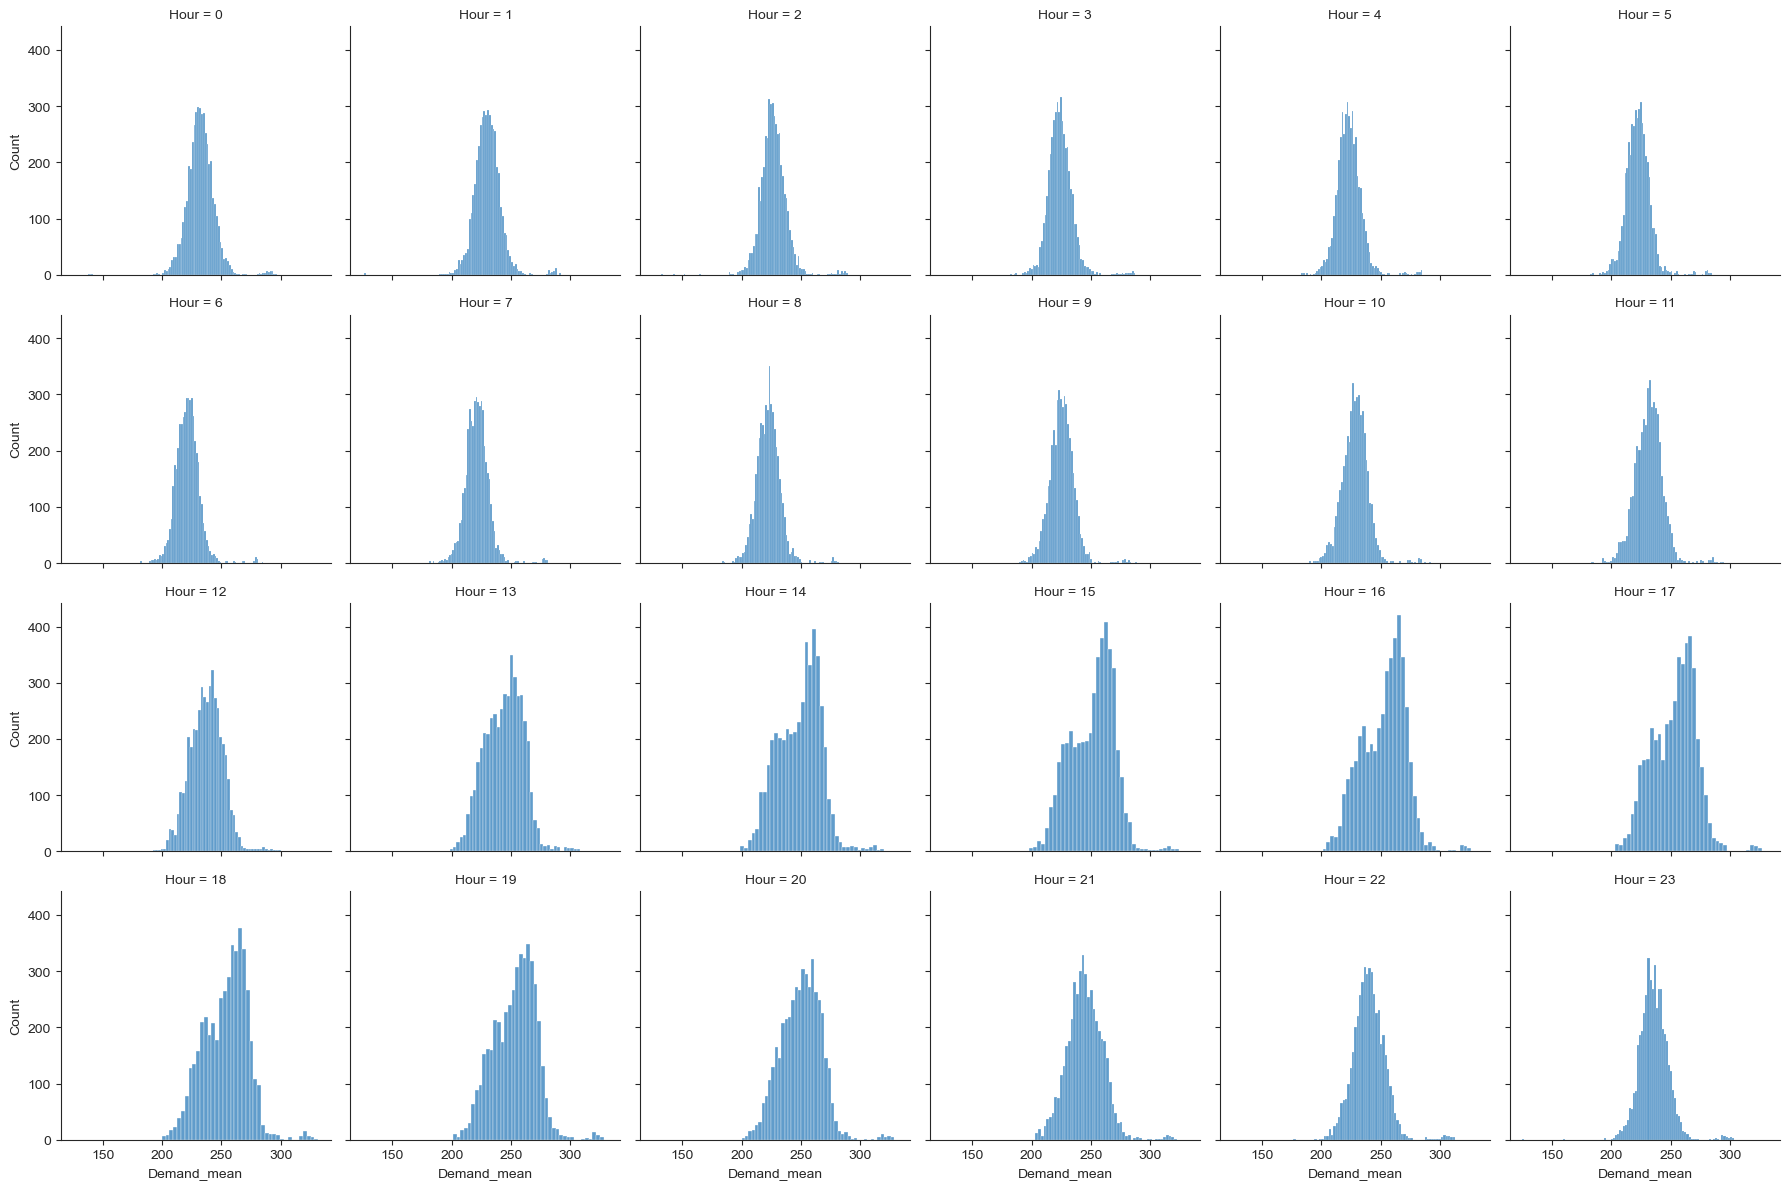

In [205]:
g = sns.FacetGrid(new_demand, col="Hour", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean", color="#2b7bba")

The hourly mean demand distributions seem for the most part normally distributed, note that these hourly distributions include both weekday and weekend demand values, hence the distributions for some of the hours have slightly fatter left tail end.

## Hourly mean demand distribution - Weekday ##

In [211]:
# weekday_index = demand_train_f.index[~((demand_train_f['Weekday'] == 5) | (demand_train_f['Weekday'] == 6))]
# weekend_index = demand_train_f.index[((demand_train_f['Weekday'] == 5) | (demand_train_f['Weekday'] == 6))]

# demand_weekday = demand_train_f.iloc[weekday_index]
# demand_weekend = demand_train_f.iloc[weekend_index]

# new_demand_weekday = demand_weekday.reset_index(drop=True)
# new_demand_weekend = demand_weekend.reset_index(drop=True)



In [215]:
weekday_index = new_demand.index[~((new_demand['Weekday'] == 5) | (new_demand['Weekday'] == 6))]
weekend_index = new_demand.index[((new_demand['Weekday'] == 5) | (new_demand['Weekday'] == 6))]

demand_weekday = new_demand.iloc[weekday_index]
demand_weekend = new_demand.iloc[weekend_index]

new_demand_weekday = demand_weekday.reset_index(drop=True)
new_demand_weekend = demand_weekend.reset_index(drop=True)

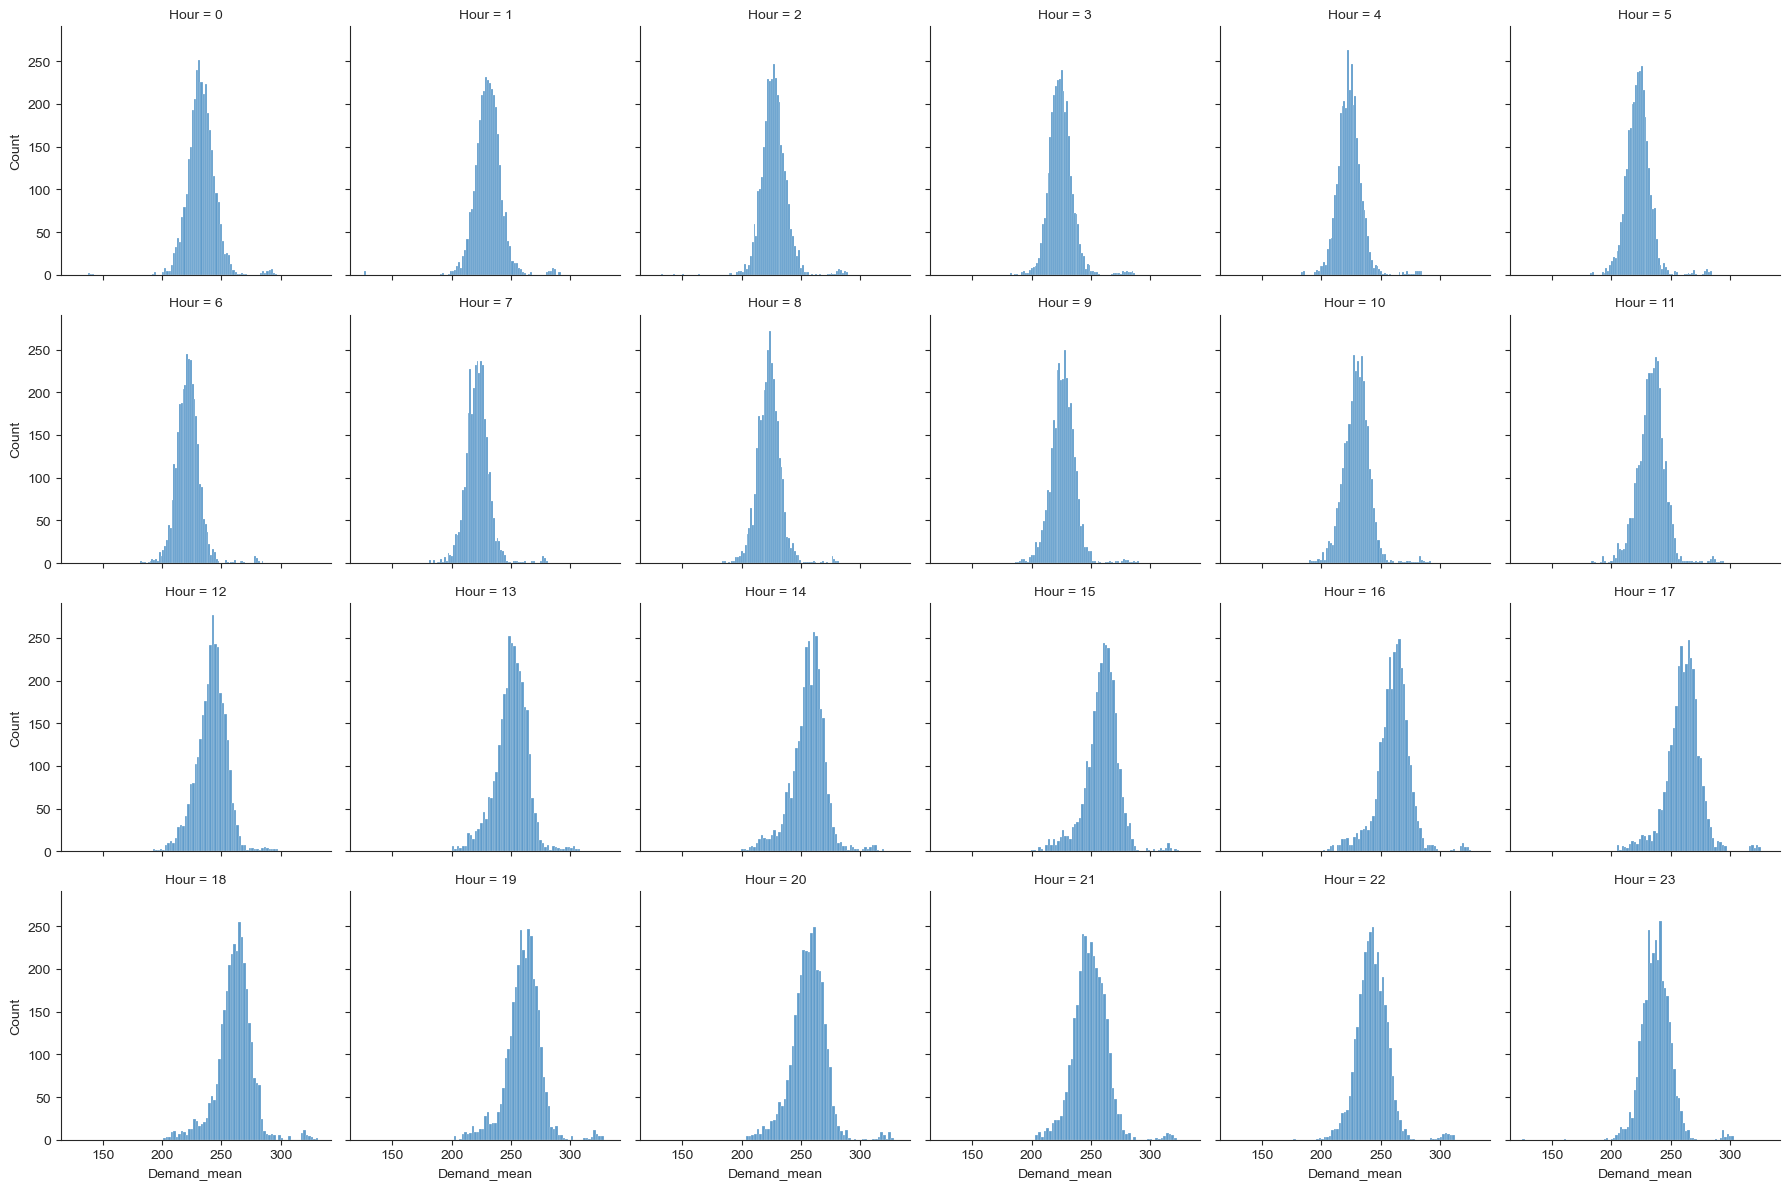

In [217]:
g = sns.FacetGrid(new_demand_weekday, col="Hour", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean", color="#2b7bba")

## Hourly mean demand distribution - Weekend ##

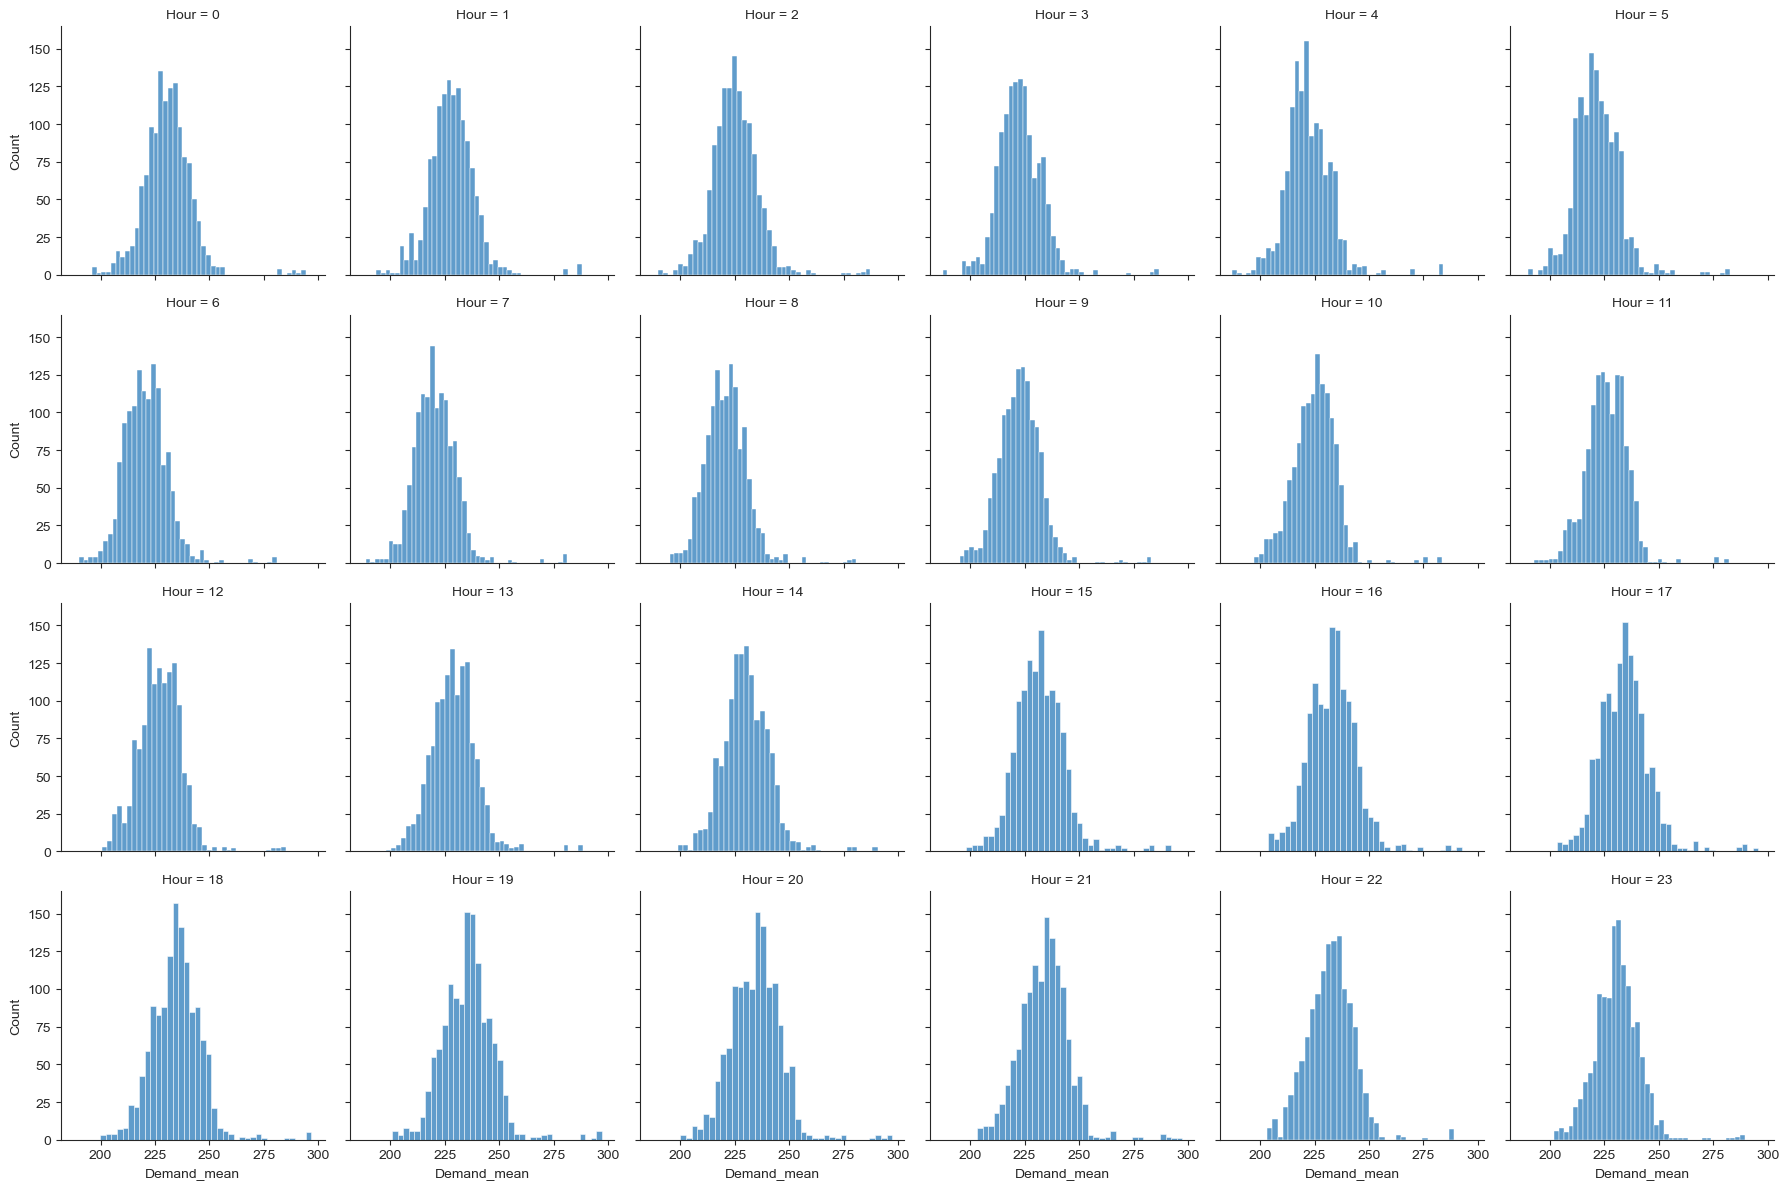

In [218]:
g = sns.FacetGrid(new_demand_weekend, col="Hour", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean", color="#2b7bba")

## Day of week mean demand distribution ##
###### Week 6: Sunday ######

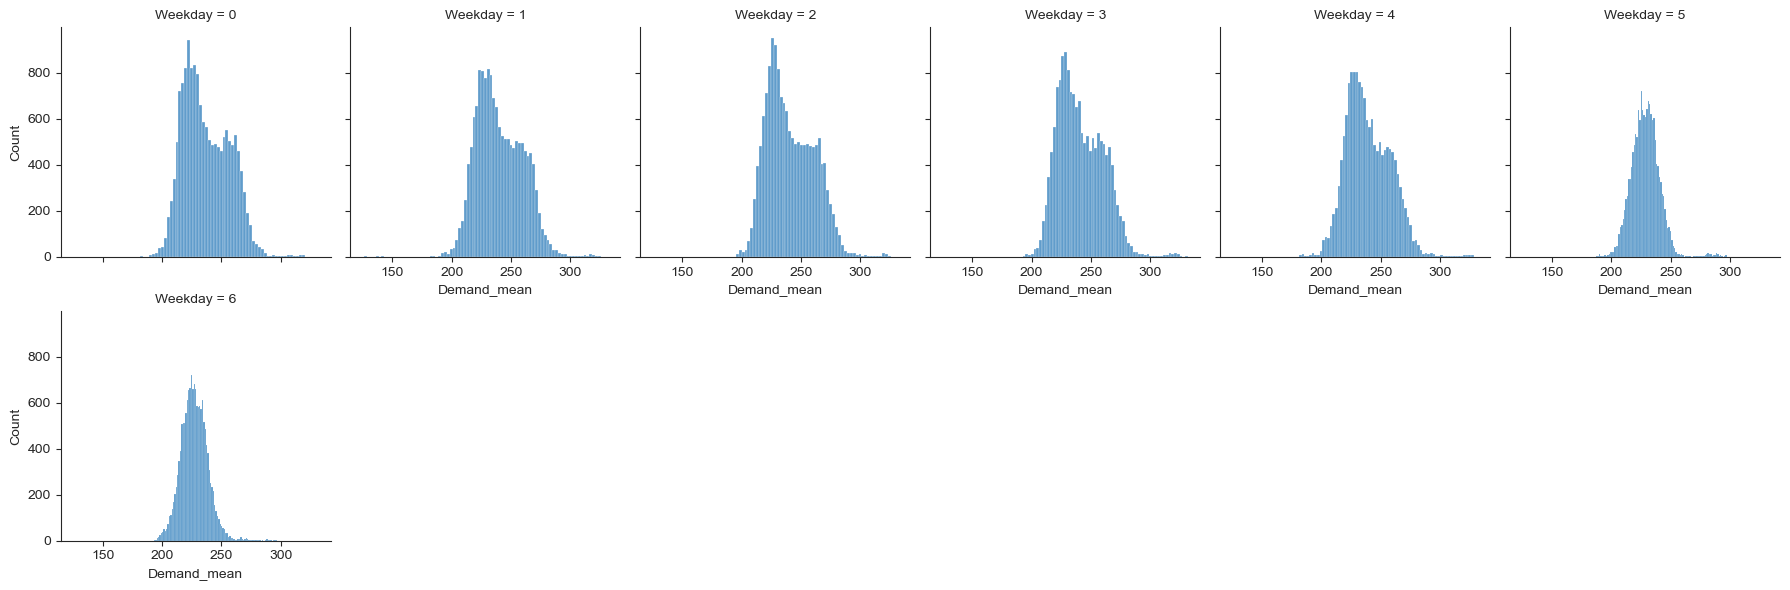

In [219]:
g = sns.FacetGrid(new_demand, col="Weekday", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean", color="#2b7bba")

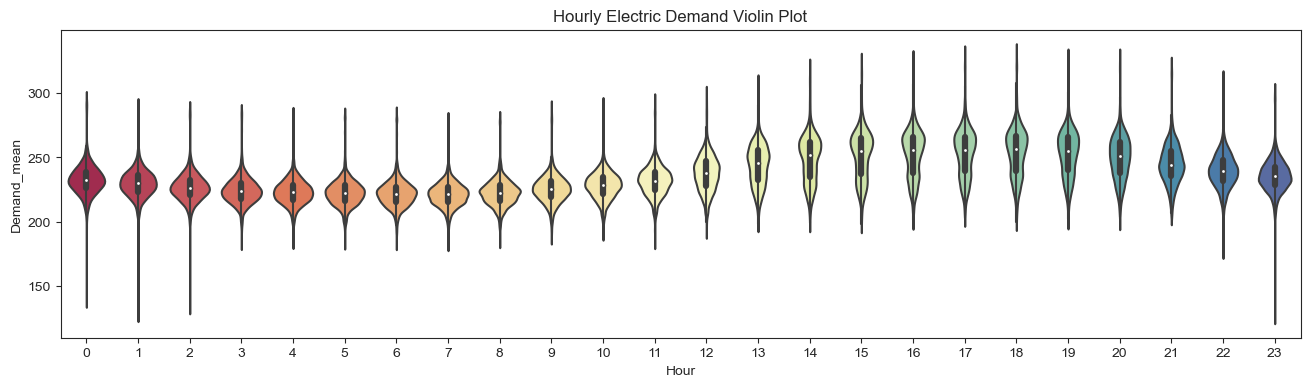

In [220]:
fig, ax = plt.subplots(figsize = (16, 4))
ax = sns.violinplot(x='Hour', y='Demand_mean', data=new_demand, palette="Spectral").set(title='Hourly Electric Demand Violin Plot')

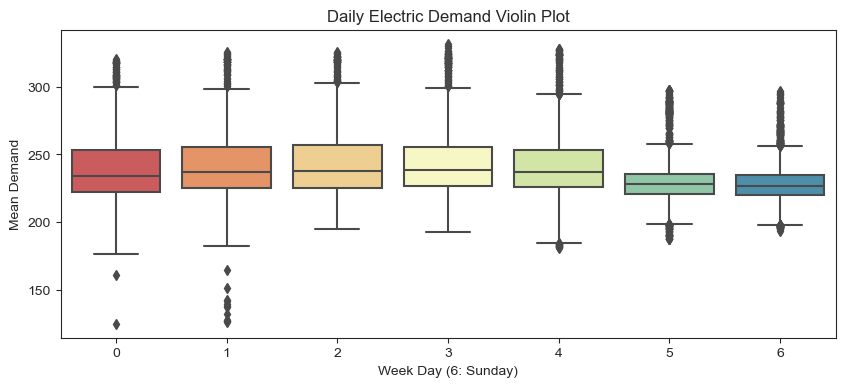

In [224]:
fig, ax = plt.subplots(figsize = (10, 4))
ax = sns.boxplot(x='Weekday', y='Demand_mean', data=new_demand,  palette="Spectral")
_ = ax.set (xlabel="Week Day (6: Sunday)", ylabel="Mean Demand", title='Daily Electric Demand Violin Plot')

### Univariate Analysis ###

In [222]:
correlation = demand_train_f.corr()['Demand_mean'].sort_values(ascending=False)
correlation

Demand_mean      1.000000
Demand_30        0.972322
Demand_45        0.968941
Demand_15        0.968851
Demand_60        0.960199
Demand_0         0.960075
Hour             0.479283
Demand_sd        0.196116
Wind_Speed       0.132359
Temperature      0.121637
Wind_Gust        0.070474
Precipitation    0.022126
Pressure         0.013447
Dew_Point        0.007311
Minute          -0.001040
DayOfMonth      -0.022975
Month           -0.084265
Weekday         -0.209925
Humidity        -0.309440
Name: Demand_mean, dtype: float64

As we expected, 'Hour' is strongly correlated to the mean hourly demand (0.5). Moreover, 'Humidity' and 'Weekday' also show significant correlation. Note that this is only a measure of linear correlation - it doesn't capture non-linear correlation.

### Multivariate Analysis ###

In [223]:
attributes_weather = ['Humidity', 'Temperature', 'WindGust', 'DewPoint', 'WindSpeed', 'Demand_mean']
attributes_temporal = ['Hour', 'Minute', 'Weekday', 'Month', 'Demand_mean']

# _ = scatter_matrix(new_demand[attributes_weather], figsize=(12,8), color="#0b559f")
_ = sns.pairplot(new_demand[attributes_weather], diag_kind='kde')

KeyError: "['WindGust', 'DewPoint', 'WindSpeed'] not in index"

Temperature and Dewpoint are highly correlated, also, Windspeed and Windgust are highly correlated

## Data Transformation ##

In [ ]:
_ = demand_train_f.hist(bins=50, figsize=(20,15))

In [ ]:
def transform_drivers (df, drivers):
    df_new = df.copy()
    for d in drivers:
        df_new[d] = Quantile_transform (df_new[d])
    return df_new

In [ ]:
drivers = ['Humidity']
demand_train_ft = transform_drivers (new_demand, drivers)   
_ = demand_train_ft.hist(bins=50, figsize=(20,15))

In [ ]:
demand_train_ft.agg(['skew', 'kurtosis']).transpose()

 ### Temporal features Data Encoding ###

The temporal features 'Hour', 'Weekday' and 'Month' are categorical, however, encoding them using dummies would not take the fact that these attributes are cyclic in nature. For instance, it would not take into account the fact that December is closer to January than September or 1 am is closer to 11 pm than to 4 am or Monday is closer to Sunday than to Wednesday. To account for this cyclic nature of the features, each value will be represented as a point in a circle using an x and y component.

In [ ]:
def temporal_feature_cyclic (data):
    
    minutes_in_hour = 60
    hours_in_day = 24
    days_in_week = 7
    months_in_year = 12
    
    df = data.copy()
    
    df['sin_minutes'] = np.sin(2*np.pi*df['Minute']/minutes_in_hour)
    df['cos_minutes'] = np.cos(2*np.pi*df['Minute']/minutes_in_hour)
    
    df['sin_hours'] = np.sin(2*np.pi*df['Hour']/hours_in_day)
    df['cos_hours'] = np.cos(2*np.pi*df['Hour']/hours_in_day)
    
    df['sin_days'] = np.sin(2*np.pi*df['Weekday']/days_in_week)
    df['cos_days'] = np.cos(2*np.pi*df['Weekday']/days_in_week)
    
    df['sin_months'] = np.sin(2*np.pi*df['Month']/months_in_year)
    df['cos_months'] = np.cos(2*np.pi*df['Month']/months_in_year)
    
    

    #df.drop(['Hour', 'Weekday', 'Month'], axis=1, inplace=True)
    
    return (df)

In [ ]:
demand_train_backup = new_demand.copy()

In [ ]:
demand_train_ft_c = temporal_feature_cyclic (demand_train_ft)

In [ ]:
demand_train_ft_c.head()

In [ ]:
demand_train_ft_c.corr()['Demand_mean'].sort_values(ascending=False)

The newly generated feature sin_hours is significantly more correlated to the mean hourly demand than the hour, moreover, the sin_days is also more correlated than Weeekdays. Pretty good! 

In [ ]:
demand_train_ft_c.columns

In [ ]:
demand_train_ft_c.drop(['Minute', 'Hour', 'Weekday', 'Month'], axis=1, inplace=True)

**The temporal feature 'Minute' is categorical. Let's convert it into dummy variables**

In [ ]:
demand_train_ft_c.columns

In [ ]:
features_autoencoder = ['Demand_0', 'Demand_15', 'Demand_30',
       'Demand_45', 'Demand_60', 'Demand_mean', 'Demand_sd', 'sin_hours',
       'cos_hours', 'sin_days', 'cos_days', 'sin_months', 'cos_months',
       'sin_minutes', 'cos_minutes', 'Humidity']

demand_train_autoencoder_t = demand_train_ft_c.copy ()

demand_train_autoencoder_t = demand_train_autoencoder_t [features_autoencoder]

In [ ]:
demand_train_autoencoder_t.head()

# Feature Scaling #

Discuss why we need feature scaling - use pipelines

In [ ]:
scaler = StandardScaler ()

# scaler for autoencoder features
scaler_autoencoder = StandardScaler ()

# demand_train_t = scaler.fit_transform(demand_train_t)
demand_train_t_autoencoder = scaler_autoencoder.fit_transform (demand_train_autoencoder_t)

## Test Dataset Treatment ##

In [ ]:
# Treat missing data for both positive and negative test dataset
positive_test = missing_treatment (positive_test)
negative_test = missing_treatment (negative_test)

In [ ]:
# generate new features for the positive and negative test datasets
positive_test = generate_features (positive_test)
negative_test = generate_features (negative_test)

In [ ]:
drivers = ['Humidity']
negative_test_t = transform_drivers (negative_test, drivers)  
positive_test_t = transform_drivers (positive_test, drivers)

In [ ]:
# Encode the feature 'Minute' using dummy variables
# **************** not encode minutes *****************
negative_test_t_e = temporal_feature_cyclic (negative_test_t)
positive_test_t_e = temporal_feature_cyclic (positive_test_t)


negative_test_t_e_d = pd.get_dummies(negative_test_t_e, columns=['Minute'])
positive_test_t_e_d = pd.get_dummies (positive_test_t_e, columns=['Minute'])


In [ ]:
positive_test_autoencoder = positive_test_t_e_d[features_autoencoder]
negative_test_autoencoder = negative_test_t_e_d[features_autoencoder]

In [ ]:
negative_test_autoencoder.head()

In [ ]:
# negative_test_t = scaler.transform (negative_test_t)
# positive_test_t = scaler.transform (positive_test_t)

negative_test_autoencoder = scaler_autoencoder.transform (negative_test_autoencoder)
positive_test_autoencoder = scaler_autoencoder.transform (positive_test_autoencoder)

# Model Training #

# Algorithms used in this project #
##### 1. Deep Learning Autoencoder #####
##### 2. Support Vector Regression #####
##### 3. Random Forest             #####
##### 4. Gradient boosting algorithm and AdaBoosting algorithm                   #####
##### 5. Linear regression #####
##### 6. Decision tree #####
##### 7. K-means #####
##### 8. Naive Bayes algorithm #####
##### 9. KNN #####
##### #####
##### #####
##### #####
##### #####
##### #####

In [ ]:
h2o.init()

In [ ]:
demand_train_h2o = h2o.H2OFrame(demand_train_t_autoencoder)
negative_test_h2o = h2o.H2OFrame (negative_test_t_e_d)
positive_test_h2o = h2o.H2OFrame (positive_test_t_e_d)

In [ ]:
demand_train_t_autoencoder_h2o = h2o.H2OFrame (demand_train_t_autoencoder)
negative_test_autoencoder_h2o = h2o.H2OFrame (negative_test_autoencoder)
positive_test_autoencoder_h2o = h2o.H2OFrame (positive_test_autoencoder)

In [ ]:
features = demand_train_t_autoencoder_h2o.columns

anomaly_model = H2OAutoEncoderEstimator(activation = "Tanh",
                               hidden = [25,14, 6],
                               epochs = 200,
                               standardize = True,
                                stopping_metric = 'MSE', 
                                loss = 'automatic',
    
                                shuffle_training_data = True,     
                               autoencoder = True,
                               l1 = 10e-5)
anomaly_model.train(x=features, training_frame = demand_train_t_autoencoder_h2o)

In [ ]:
negative_test_rec_error=anomaly_model.anomaly (negative_test_autoencoder_h2o)
positive_test_rec_error=anomaly_model.anomaly (positive_test_autoencoder_h2o)
train_rec_error = anomaly_model.anomaly (demand_train_t_autoencoder_h2o)

In [ ]:
negative_mse = negative_test_rec_error.as_data_frame()
positive_mse = positive_test_rec_error.as_data_frame()
train_mse = train_rec_error.as_data_frame()

In [ ]:
_ = sns.lineplot (x=negative_mse.index, y=negative_mse['Reconstruction.MSE'], color="#2b7bba")

In [ ]:
_ = sns.lineplot (x=positive_mse.index, y=positive_mse['Reconstruction.MSE'], color="Salmon")

In [ ]:
_ = sns.lineplot (x=train_mse.index, y=train_mse['Reconstruction.MSE'],  color="#2b7bba")

In [ ]:
_ = sns.histplot (positive_mse['Reconstruction.MSE'], color="Salmon")
_ = sns.histplot (negative_mse['Reconstruction.MSE'], color="#2b7bba")

In [ ]:
def confusion_matrix (negative_mse, positive_mse, neg_round, pos_round):
    
    neg = negative_mse['Reconstruction.MSE'].values
    pos = positive_mse['Reconstruction.MSE'].values
    
    errors_neg = np.around (neg,neg_round) 
    errors_pos = np.around (pos,pos_round)
    
    errors = np.concatenate ((errors_neg, errors_pos))
    thresholds = np.unique (errors)
    
    
    TPR = []
    FPR = []
    TNR = []
    FNR = []
    
    for t in thresholds:
        tpr = np.count_nonzero(pos > t)/len(pos)
        fpr = np.count_nonzero(neg > t)/len(neg)
        
        fnr = np.count_nonzero(pos <= t)/len(pos)
        tnr = np.count_nonzero(neg <= t)/len(neg)
        
        TPR.append (np.around(tpr,2))
        FNR.append (np.around(fnr,2))
        
        
        TNR.append (np.around(tnr,2))
        FPR.append (np.around(fpr,2))
       
        
    pos_rates = pd.DataFrame (TPR, FPR)
    pos_rates.reset_index(inplace=True)
    pos_rates.rename(columns={'index': "TPR", 0:"FPR"}, inplace=True)
    neg_rates = pd.DataFrame (TNR, FNR)
    neg_rates.reset_index(inplace=True)
    neg_rates.rename(columns={'index': "TNR", 0:"FNR"}, inplace=True)
        
    return TPR, FPR, TNR, FNR

In [ ]:
def plot_roc_curve(fpr, tpr):

    fig, ax = plt.subplots(ncols=1, nrows=1) 
                                         
    ax.set_ylabel("True Positive Rate")
    ax.set_xlabel("False Positive Rate")

    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

In [ ]:
TPR, FPR, TNR, FNR = confusion_matrix (negative_mse, positive_mse, 5, 4)
_ = plot_roc_curve (FPR, TPR)

In [ ]:
demand_train.head()

In [ ]:
anomaly_model._model_json['output']['variable_importances'].as_data_frame()
# plotting the variable importance

fig, ax = plt.subplots(figsize = (12, 8))

variables = anomaly_model._model_json['output']['variable_importances']['variable']
var = variables[0:22]
y_pos = np.arange(len(var))

scaled_importance = anomaly_model._model_json['output']['variable_importances']['scaled_importance']
sc = scaled_importance[0:22]

ax.barh(y_pos, sc, align='center', color='blue', ecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(variables)
ax.invert_yaxis()
ax.set_xlabel('Scaled Importance')
ax.set_title('Variable Importance')
plt.show()

## Fitting data to a distribution ##

In [ ]:
%matplotlib inline

import warnings
import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels as sm
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.figsize'] = (16.0, 12.0)
matplotlib.style.use('ggplot')

# Create models from data
def best_fit_distribution(data, bins=200, ax=None):
    """Model data by finding best fit distribution to data"""
    # Get histogram of original data
    y, x = np.histogram(data, bins=bins, density=True)
    x = (x + np.roll(x, -1))[:-1] / 2.0

    # Distributions to check
    
    DISTRIBUTIONS = [        
        st.alpha,st.anglit,st.arcsine,st.beta,st.betaprime,st.bradford,st.burr,st.cauchy,st.chi,st.chi2,st.cosine,
        st.dgamma,st.dweibull,st.erlang,st.expon,st.exponnorm,st.exponweib,st.exponpow,st.f,st.fatiguelife,st.fisk,
        st.foldcauchy,st.foldnorm, st.genlogistic,st.genpareto,st.gennorm,st.genexpon,
        st.genextreme,st.gausshyper,st.gamma,st.gengamma,st.genhalflogistic,st.gilbrat,st.gompertz,st.gumbel_r,
        st.gumbel_l,st.halfcauchy,st.halflogistic,st.halfnorm,st.halfgennorm,st.hypsecant,st.invgamma,st.invgauss,
        st.pareto,st.pearson3,st.powerlaw,st.powerlognorm,st.weibull_max,st.wrapcauchy
    ]

    # Best holders
    best_distribution = st.norm
    best_params = (0.0, 1.0)
    best_sse = np.inf

    # Estimate distribution parameters from data
    for distribution in DISTRIBUTIONS:

        # Try to fit the distribution
        try:
            # Ignore warnings from data that can't be fit
            with warnings.catch_warnings():
                warnings.filterwarnings('ignore')

                # fit dist to data
                params = distribution.fit(data)

                # Separate parts of parameters
                arg = params[:-2]
                loc = params[-2]
                scale = params[-1]

                # Calculate fitted PDF and error with fit in distribution
                pdf = distribution.pdf(x, loc=loc, scale=scale, *arg)
                sse = np.sum(np.power(y - pdf, 2.0))

                # if axis pass in add to plot
                try:
                    if ax:
                        pd.Series(pdf, x).plot(ax=ax)
                    end
                except Exception:
                    pass

                # identify if this distribution is better
                if best_sse > sse > 0:
                    best_distribution = distribution
                    best_params = params
                    best_sse = sse

        except Exception:
            pass

    return (best_distribution.name, best_params)

def make_pdf(dist, params, size=10000):
    """Generate distributions's Probability Distribution Function """

    # Separate parts of parameters
    arg = params[:-2]
    loc = params[-2]
    scale = params[-1]

    # Get sane start and end points of distribution
    start = dist.ppf(0.01, *arg, loc=loc, scale=scale) if arg else dist.ppf(0.01, loc=loc, scale=scale)
    end = dist.ppf(0.99, *arg, loc=loc, scale=scale) if arg else dist.ppf(0.99, loc=loc, scale=scale)

    # Build PDF and turn into pandas Series
    x = np.linspace(start, end, size)
    y = dist.pdf(x, loc=loc, scale=scale, *arg)
    pdf = pd.Series(y, x)

    return pdf

# Load data from statsmodels datasets

data = peak_demand_hours ['Demand_mean']
# data = low_demand_hours ['Demand_mean']
# data = demand_weekend['Demand_mean']

# Plot for comparison
plt.figure(figsize=(12,8))
ax = data.plot(kind='hist', bins=50, alpha=0.5)
# Save plot limits
dataYLim = ax.get_ylim()

# Find best fit distribution
best_fit_name, best_fit_params = best_fit_distribution(data, 200, ax)
best_dist = getattr(st, best_fit_name)

# Update plots
ax.set_ylim(dataYLim)
ax.set_title(u'El Niño sea temp.\n All Fitted Distributions')
ax.set_xlabel(u'Temp (°C)')
ax.set_ylabel('Frequency')

# Make PDF with best params 
pdf = make_pdf(best_dist, best_fit_params)

# Display
plt.figure(figsize=(12,8))
ax = pdf.plot(lw=2, label='PDF', legend=True)
data.plot(kind='hist', bins=50, alpha=0.5, label='Data', legend=True, ax=ax)

param_names = (best_dist.shapes + ', loc, scale').split(', ') if best_dist.shapes else ['loc', 'scale']
param_str = ', '.join(['{}={:0.2f}'.format(k,v) for k,v in zip(param_names, best_fit_params)])
dist_str = '{}({})'.format(best_fit_name, param_str)

ax.set_title(u'El Niño sea temp. with best fit distribution \n' + dist_str)
ax.set_xlabel(u'Temp. (°C)')
ax.set_ylabel('Frequency')